In [1]:
import pandas as pd
import numpy as np

table1_cols = ["summary_id" ,"pickDate", "count", "itemCode", "itemDescription", "pickQty", "ordQty", "pickedStorageBin", "pickerId", "pickHeNo", "storageSectionId", "totalTimeSeconds", "perQtyTime"]
table2_cols = ["space_id", "st_sec_id", "totalCount", "usedCount", "createdDate", "utilization"]

# =====================================================================
# 1. LOAD THE RAW DATA & PARSE DATES
# =====================================================================
table1 = pd.read_csv('/home/adityaa/Desktop/internship/data/tbl_pick_summary.csv', header = None, names = table1_cols)
table2 = pd.read_csv('/home/adityaa/Desktop/internship/data/tblspace.csv', header = None, names = table2_cols)

table3 = pd.read_csv('/home/adityaa/Desktop/internship/data/putaway_summary.csv', header=1, low_memory=False)
table3.columns = ['summary_id', 'putawayDate', 'count', 'itemCode', 'putAwayQty',
                     'ordQty', 'storageBin', 'storageSectionId', 'totalTimeinSeconds',
                     'perQtyTime', 'item_text', 'proposed_st_bin']

# Convert dates to datetime objects immediately
table1['pickDate'] = pd.to_datetime(table1['pickDate'], errors='coerce')
table2['createdDate'] = pd.to_datetime(table2['createdDate'], errors='coerce')
table3['putaway_Date'] = pd.to_datetime(table3['putawayDate'], format='%Y-%m-%d', errors='coerce')

# =====================================================================
# 2. TIME-BASED SPLIT FOR PURE TRAINING (UP TO DEC 2025 ONLY)
# =====================================================================
table1 = table1[table1['pickDate'].dt.year <= 2025].copy()
table2 = table2[table2['createdDate'].dt.year <= 2025].copy()
table3 = table3[table3['putaway_Date'].dt.year <= 2025].copy()

print("✅ Training Data Locked (2024 - 2025 only). Ready for feature engineering.")

✅ Training Data Locked (2024 - 2025 only). Ready for feature engineering.


In [2]:
print(table1.isnull().sum())

summary_id           0
pickDate             0
count                0
itemCode             0
itemDescription     32
pickQty              0
ordQty               0
pickedStorageBin     0
pickerId             9
pickHeNo             0
storageSectionId     0
totalTimeSeconds     0
perQtyTime           0
dtype: int64


In [3]:
print(table2.isnull().sum())

space_id        0
st_sec_id      37
totalCount      0
usedCount       0
createdDate     0
utilization     0
dtype: int64


In [4]:
print(table3.isnull().sum())

summary_id            0
putawayDate           0
count                 0
itemCode              0
putAwayQty            0
ordQty                0
storageBin            0
storageSectionId      0
totalTimeinSeconds    0
perQtyTime            0
item_text             2
proposed_st_bin       0
putaway_Date          0
dtype: int64


Picking Data Pre-Processing

In [5]:
print("--- Initial Shapes ---")
print("Table 1:", table1.shape)
print("Table 2:", table2.shape)
print("-" * 22)

# 1. Handle basic missing values with placeholders
table1['itemDescription'] = table1['itemDescription'].fillna('UNKNOWN_ITEM')
table1['pickerId'] = table1['pickerId'].fillna('UNKNOWN_PICKER')
table2_clean = table2.dropna(subset=['st_sec_id']).copy()

# 2. Standardize linking columns as clean strings
table1['storageSectionId'] = table1['storageSectionId'].astype(str).str.strip().str.upper()
table2_clean['st_sec_id'] = table2_clean['st_sec_id'].astype(str).str.strip().str.upper()

# =====================================================================
# STEP 2.5: REMOVE PURE NUMERIC ZONE NAME ANOMALIES (e.g., '5')
# =====================================================================
# This keeps only rows where st_sec_id does NOT consist of pure numeric digits
# regex=True ensures pandas reads ^\d+$ as a pattern, na=False handles hidden empty strings safely
table2_clean = table2_clean[~table2_clean['st_sec_id'].str.contains(r'^\d+$', regex=True, na=False)]

# Optional: Apply same protection to table1 if any pure digits sneaked in there too
table1 = table1[~table1['storageSectionId'].str.contains(r'^\d+$', regex=True, na=False)]


# 3. Convert text dates to real datetime objects
table1['pickDate'] = pd.to_datetime(table1['pickDate'])
table2_clean['createdDate'] = pd.to_datetime(table2_clean['createdDate'])

# 4. Remove exact duplicate rows
table1 = table1.drop_duplicates()
table2_clean = table2_clean.drop_duplicates()

# 5. Drop logical anomalies and extreme scanner time errors (Over 2 hours / 7200s)
table1 = table1[
    (table1['pickQty'] >= 0) & 
    (table1['ordQty'] > 0) & 
    (table1['totalTimeSeconds'] > 0) & 
    (table1['totalTimeSeconds'] <= 7200)
]

table2_clean = table2_clean[table2_clean['totalCount'] > 0]

print("--- Preprocessing Completed! ---")
print("Cleaned Table 1 Rows:", table1.shape)
print("Cleaned Table 2 Rows:", table2_clean.shape)

--- Initial Shapes ---
Table 1: (351654, 13)
Table 2: (16026, 6)
----------------------
--- Preprocessing Completed! ---
Cleaned Table 1 Rows: (346895, 13)
Cleaned Table 2 Rows: (15871, 6)


In [6]:
# =====================================================================
# STEP 2.2: STRUCTURAL WAREHOUSE GUARDRAIL & REGEX PURGE
# =====================================================================
import re

# Strict validation: Must be exactly a 2-letter uppercase zone, OR one of your named exceptions
def is_valid_warehouse_zone(zone_id):
    zone_str = str(zone_id).strip().upper()
    # Check for specific valid 3-letter or operational codes
    if zone_str in ['LOC', 'DP', 'AL', 'RE']:
        return True
    # Check if it's a clean 2-letter alphabetic zone code (AA, AB... BJ)
    return bool(re.match(r'^[A-Z]{2}$', zone_str))

# Clean trailing spaces and drop corrupt alphanumeric system codes
table1['storageSectionId'] = table1['storageSectionId'].astype(str).str.strip().str.upper()
table1 = table1[table1['storageSectionId'].apply(is_valid_warehouse_zone)].copy()

table2['st_sec_id'] = table2['st_sec_id'].astype(str).str.strip().str.upper()
table2_clean = table2[table2['st_sec_id'].apply(is_valid_warehouse_zone)].copy()

# Print defensive confirmation to verify data purity
print("--- Alphanumeric System Noise Successfully Purged ---")
print(f"Active Clean Zones in Table 1: {table1['storageSectionId'].nunique()}")
print(f"Active Clean Zones in Table 2: {table2_clean['st_sec_id'].nunique()}")

# =====================================================================
# STEP 2.7: FILTER TABLE 2 TO MATCH TABLE 1 ZONES ONLY
# =====================================================================

# 1. Extract the definitive list of active zones from Table 1
active_picking_zones = table1['storageSectionId'].unique()

# 2. Find and count the mismatches before deleting them
mismatched_rows_df = table2_clean[~table2_clean['st_sec_id'].isin(active_picking_zones)]
unique_mismatched_zones = mismatched_rows_df['st_sec_id'].nunique()
total_mismatched_rows = len(mismatched_rows_df)

print("="*60)
print("          MISMATCHED ZONES ELIMINATION REPORT              ")
print("="*60)
print(f" -> Number of unique mismatched zones in Table 2: {unique_mismatched_zones}")
print(f" -> Total rows affected and targeted for deletion: {total_mismatched_rows}")

# 3. Delete the mismatched zones by keeping ONLY the valid ones
# The tilde operator (~) is dropped here because we want an 'inner' filter match
table2_clean = table2_clean[table2_clean['st_sec_id'].isin(active_picking_zones)].copy()

print("\n" + "-"*50)
print(" ✅ DELETION COMPLETE!")
print(f" -> Cleaned Table 2 Rows Remaining: {table2_clean.shape[0]}")
print(f" -> Cleaned Table 2 Unique Zones:   {sorted(table2_clean['st_sec_id'].unique().tolist())}")
print("="*60)

--- Alphanumeric System Noise Successfully Purged ---
Active Clean Zones in Table 1: 24
Active Clean Zones in Table 2: 25
          MISMATCHED ZONES ELIMINATION REPORT              
 -> Number of unique mismatched zones in Table 2: 1
 -> Total rows affected and targeted for deletion: 1

--------------------------------------------------
 ✅ DELETION COMPLETE!
 -> Cleaned Table 2 Rows Remaining: 13630
 -> Cleaned Table 2 Unique Zones:   ['AA', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ', 'AK', 'AL', 'BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG', 'BH', 'BI', 'BJ', 'DP', 'LOC']


Putaway Data Pre-Processing

In [7]:
# =====================================================================
# Putaway Data Pre-Processing & Clean Structural Clean-up Layer
# =====================================================================

# 1. TYPE CONVERSIONS & DATETIME HANDLING (Enforce rigid ISO-format parsing)
table3['putaway_Date'] = pd.to_datetime(table3['putawayDate'], format='%Y-%m-%d', errors='coerce')
table3['putawayMonth'] = table3['putaway_Date'].dt.to_period('M').astype(str)

numeric_cols = ['count', 'putAwayQty', 'ordQty', 'totalTimeinSeconds', 'perQtyTime']
for col in numeric_cols:
    table3[col] = pd.to_numeric(table3[col], errors='coerce')

# 2. STRING SANITIZATION & NULL-ZONE HANDLING
table3['storageSectionId'] = table3['storageSectionId'].astype(str).str.upper().str.strip()
table3['storageSectionId'] = table3['storageSectionId'].replace(['NAN', 'NAT', 'NONE', ''], np.nan)

# Fix lowercase/whitespace variances inside literal text string columns
table3['storageBin'] = table3['storageBin'].astype(str).str.upper().str.strip()
table3['proposed_st_bin'] = table3['proposed_st_bin'].astype(str).str.upper().str.strip()
table3['item_text'] = table3['item_text'].fillna('Unknown_Item')

# =====================================================================
# STEP 2.8: PURGE ALPHANUMERIC NOISE (G01, ROOM2, ETC.) FROM TABLE 3
# =====================================================================
# Run the exact same regex validation filter to drop data ghosts/system templates
# (Uses the is_valid_warehouse_zone function defined in your previous cells)
table3 = table3[table3['storageSectionId'].apply(is_valid_warehouse_zone)].copy()

# =====================================================================
# 3. STRICT ML PURGE LAYER (Dropping Technical Anomalies & Nulls)
# =====================================================================
initial_rows = len(table3)

# Filter 1: Drop rows missing the structural Zone ID (essential mapping key)
table3 = table3.dropna(subset=['storageSectionId'])

# Filter 2: Drop rows where calculated time variables are missing/NaN
table3 = table3.dropna(subset=['totalTimeinSeconds', 'perQtyTime'])

# Filter 3: Drop rows where times are zero or negative 
table3 = table3[(table3['totalTimeinSeconds'] > 0) & (table3['perQtyTime'] > 0)]

rows_removed = initial_rows - len(table3)
print("="*60)
print("         TABLE 3 TECHNICAL ANOMALY PURGE REPORT")
print("="*60)
print(f" -> Purged {rows_removed} rows ({ (rows_removed/initial_rows)*100 :.2f}% of data) due to nulls or zero times.")

# =====================================================================
# 4. VALUE BOUNDS FOR VALID DATA
# =====================================================================
# Ensure actual physical quantities inside valid transactions cannot run negative
for col in ['putAwayQty', 'ordQty']:
    table3[col] = table3[col].clip(lower=0)

# Quick sync logical rule: If a physical drop occurred but order quantity shows 0, synchronize it
zero_ord_mask = (table3['ordQty'] == 0) & (table3['putAwayQty'] > 0)
table3.loc[zero_ord_mask, 'ordQty'] = table3.loc[zero_ord_mask, 'putAwayQty']

# =====================================================================
# 5. EXTREME TIME FILTER — Explicit Head Confirmation Guardrail
# Cutoff: 1 hour (3,600 seconds)
# Justification: Validated operational ceiling threshold for an individual ticket
# =====================================================================
MAX_PUTAWAY_SECONDS = 1 * 3600  # 1 hour maximum limit 

rows_before_filter = len(table3)
table3 = table3[table3['totalTimeinSeconds'] <= MAX_PUTAWAY_SECONDS].copy()
rows_removed_extreme = rows_before_filter - len(table3)

print("\n" + "-"*50)
print(" ⏱️ EXTREME TIME FILTER SUMMARY (1-HOUR LIMIT)")
print("-" * 50)
print(f" -> Genuine training rows entering filter: {rows_before_filter:,}")
print(f" -> Removed screen lag errors (> 1 hr)    : {rows_removed_extreme:,} rows ({rows_removed_extreme/rows_before_filter*100:.2f}%)")
print(f" -> Retained true operational actions    : {len(table3):,} rows ({len(table3)/rows_before_filter*100:.2f}%)")
print(f" -> Cleaned Table 3 Unique Training Zones: {sorted(table3['storageSectionId'].unique().tolist())}")
print("="*60 + "\n")

         TABLE 3 TECHNICAL ANOMALY PURGE REPORT
 -> Purged 1455 rows (0.63% of data) due to nulls or zero times.

--------------------------------------------------
 ⏱️ EXTREME TIME FILTER SUMMARY (1-HOUR LIMIT)
--------------------------------------------------
 -> Genuine training rows entering filter: 228,224
 -> Removed screen lag errors (> 1 hr)    : 185,741 rows (81.39%)
 -> Retained true operational actions    : 42,483 rows (18.61%)
 -> Cleaned Table 3 Unique Training Zones: ['AA', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ', 'AK', 'AL', 'BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG', 'BH', 'BI', 'BJ', 'DP', 'JF', 'LOC']



1. Zone Pick Rate Score (which physical zones are layout-friendly)

In [8]:
# =====================================================================
# STEP 1: PREPROCESSING & FORMATTING BASES
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].str.upper()
table1['pickMonth'] = table1['pickDate'].dt.to_period('M')

print("--- Parameter 1: Zone Pick Rate Score Engine (Operational Baseline) ---")


# =====================================================================
# STEP 2: AGGREGATE TO MONTH-ZONE-SKU LAYER
# =====================================================================
sku_hourly_df = table1.groupby(['itemCode', 'pickMonth', 'storageSectionId']).agg(
    total_picked_units=('pickQty', 'sum'),
    total_pickup_time_seconds=('totalTimeSeconds', 'sum')
).reset_index()

# Convert raw seconds into hours
sku_hourly_df['pickup_time_hours'] = sku_hourly_df['total_pickup_time_seconds'] / 3600.0


# =====================================================================
# STEP 3: CALCULATE ROBUST WAREHOUSE-WIDE MEDIAN SPEEDS PER SKU
# =====================================================================
# Using MEDIAN instead of MAX completely ignores those 2-second freak logs!
# Before computing pick rates, remove unrealistically fast transactions
# Minimum 30 seconds per transaction to avoid inflated rates
sku_hourly_df = sku_hourly_df[sku_hourly_df['total_pickup_time_seconds'] >= 30]

sku_median_rates = sku_hourly_df.groupby('itemCode').agg(
    target_rate=('total_picked_units', lambda x: np.median(x / (sku_hourly_df.loc[x.index, 'pickup_time_hours'] + 0.0001)))
).reset_index()

# Merge this clean median target baseline back to individual records
sku_hourly_df = pd.merge(sku_hourly_df, sku_median_rates, on='itemCode', how='left')


# =====================================================================
# STEP 4: SCORE METRIC NORMALIZATION
# =====================================================================
# Actual Picks/Hr for this month-zone setup
sku_hourly_df['actual_rate'] = sku_hourly_df['total_picked_units'] / (sku_hourly_df['pickup_time_hours'] + 0.0001)

# Score = (Actual Rate / Median Target Rate) * 100
# We clip it at 100% so that zones performing better than the median don't inflate the average map
sku_hourly_df['sku_velocity_score'] = (sku_hourly_df['actual_rate'] / (sku_hourly_df['target_rate'] + 0.0001)) * 100
sku_hourly_df['sku_velocity_score'] = sku_hourly_df['sku_velocity_score'].clip(upper=100.0)


# =====================================================================
# STEP 5: MACRO ZONE AGGREGATION & UPDATED OPERATIONAL THRESHOLD
# =====================================================================
zone_pick_rate_df = sku_hourly_df.groupby(['pickMonth', 'storageSectionId']).agg(
    Zone_Pick_Rate_Score=('sku_velocity_score', 'mean')
).reset_index()

# Updated Threshold: Changed from a rigid 98% to a realistic warehouse baseline of 70%
zone_pick_rate_df['Threshold_70_Achieved'] = zone_pick_rate_df['Zone_Pick_Rate_Score'] >= 70.0


# =====================================================================
# STEP 6: OUTPUT & PERFORMANCE LOGGING
# =====================================================================
print("\n--- Adjusted Zone Pick Rate Matrix (First 20 Rows) ---")
columns_to_show = ['pickMonth', 'storageSectionId', 'Zone_Pick_Rate_Score', 'Threshold_70_Achieved']
print(zone_pick_rate_df[columns_to_show].head(20).to_string(index=False))

failed_efficiency_zones = zone_pick_rate_df[zone_pick_rate_df['Threshold_70_Achieved'] == False]
passed_efficiency_zones = zone_pick_rate_df[zone_pick_rate_df['Threshold_70_Achieved'] == True]

print("\n" + "="*60)
print("PARAMETER 2 BOTTLENECK AUDIT REPORT (70% Target)")
print("="*60)
print(f"Total rows in summary: {len(zone_pick_rate_df)}")
print(f"Efficient Month-Zone Blocks (>= 70): {len(passed_efficiency_zones)} rows")
print(f"Failing Month-Zone Blocks (< 70): {len(failed_efficiency_zones)} rows")

--- Parameter 1: Zone Pick Rate Score Engine (Operational Baseline) ---

--- Adjusted Zone Pick Rate Matrix (First 20 Rows) ---
pickMonth storageSectionId  Zone_Pick_Rate_Score  Threshold_70_Achieved
  2024-03               AA             62.122422                  False
  2024-03               AB             68.527640                  False
  2024-03               AC             63.073001                  False
  2024-03               AD             66.484165                  False
  2024-03               AE             63.514170                  False
  2024-03               AF             58.476978                  False
  2024-03               AG             60.624461                  False
  2024-03               AH             56.833879                  False
  2024-03               AI             73.650677                   True
  2024-03               AJ             66.684500                  False
  2024-03               AK             60.082655                  False
  2024-0

2. SKU & Zone Throughput (where the high-volume demand is shifting)

In [9]:
# =====================================================================
# STEP 1: STANDARDIZE FORMATS
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].str.upper()
table1['pickMonth'] = table1['pickDate'].dt.to_period('M')

print("--- Parameter 2: Throughput Optimization Engine ---")


# =====================================================================
# STEP 2: ZONE-LEVEL CALCULATIONS (Macro Health)
# =====================================================================
# Group by Month and Zone to get total units and time per section
zone_throughput_df = table1.groupby(['pickMonth', 'storageSectionId']).agg(
    zone_units=('pickQty', 'sum'),
    zone_time=('totalTimeSeconds', 'sum')
).reset_index()

# Calculate Zone Throughput (with defensive offset to avoid division by zero)
zone_throughput_df['zone_throughput'] = zone_throughput_df['zone_units'] / (zone_throughput_df['zone_time'] + 0.001)

# Find the Best Zone Throughput per month to use as a 100% benchmark
best_zone_df = zone_throughput_df.groupby('pickMonth')['zone_throughput'].max().reset_index()
best_zone_df.rename(columns={'zone_throughput': 'best_zone_throughput'}, inplace=True)

# Merge back and calculate your exact Normalized Score formula
zone_throughput_df = pd.merge(zone_throughput_df, best_zone_df, on='pickMonth', how='left')
zone_throughput_df['Normalized_Score'] = (zone_throughput_df['zone_throughput'] / zone_throughput_df['best_zone_throughput']) * 100


# =====================================================================
# STEP 3: SKU-LEVEL CALCULATIONS (Micro Speed)
# =====================================================================
# Group by Item Code, Month, and Zone
sku_throughput_df = table1.groupby(['itemCode', 'pickMonth', 'storageSectionId']).agg(
    total_picked_units=('pickQty', 'sum'),
    total_pickup_time=('totalTimeSeconds', 'sum')
).reset_index()

# Calculate SKU Throughput using your exact formula
sku_throughput_df['SKU_Throughput'] = sku_throughput_df['total_picked_units'] / (sku_throughput_df['total_pickup_time'] + 0.001)


# =====================================================================
# STEP 4: COMBINE BOTH LAYERS via LEFT JOIN
# =====================================================================
# Map the zone Normalized Score into the individual SKU records
final_matrix = pd.merge(
    sku_throughput_df, 
    zone_throughput_df[['pickMonth', 'storageSectionId', 'Normalized_Score']], 
    on=['pickMonth', 'storageSectionId'], 
    how='left'
)


# =====================================================================
# STEP 5: DUAL-THRESHOLD COMBINED FILTERING
# =====================================================================
# Dynamically calculate the top 98th percentile speed baseline for SKUs
sku_98th_percentile_speed = final_matrix['SKU_Throughput'].quantile(0.98)

# Apply independent pass/fail boolean checks for auditing
final_matrix['SKU_Speed_Pass'] = final_matrix['SKU_Throughput'] >= sku_98th_percentile_speed
final_matrix['Zone_Score_Pass'] = final_matrix['Normalized_Score'] >= 98.0

# Combine both criteria: True only if BOTH the SKU is high-speed AND the Zone is top-tier
final_matrix['Dual_Threshold_Pass'] = final_matrix['SKU_Speed_Pass'] & final_matrix['Zone_Score_Pass']


# =====================================================================
# STEP 6: PRINT CONSOLIDATED REPORT PERFORMANCE
# =====================================================================
print(f"\nCalculated 98th Percentile SKU Speed Baseline: {sku_98th_percentile_speed:.6f} units/sec")

print("\n--- Final Consolidated Throughput Matrix (First 20 Rows) ---")
dual_columns_to_view = [
    'itemCode', 'pickMonth', 'storageSectionId', 
    'SKU_Throughput', 'SKU_Speed_Pass',
    'Normalized_Score', 'Zone_Score_Pass', 
    'Dual_Threshold_Pass'
]
print(final_matrix[dual_columns_to_view].head(20).to_string(index=False))


# =====================================================================
# STEP 7: COMPREHENSIVE PERFORMANCE SUMMARY
# =====================================================================
total_rows = len(final_matrix)
total_passed = final_matrix['Dual_Threshold_Pass'].sum()
total_failed = total_rows - total_passed

# Isolate critical operational misalignments (Fast SKUs trapped in a slow layout)
trapped_superstars = final_matrix[(final_matrix['SKU_Speed_Pass'] == True) & (final_matrix['Zone_Score_Pass'] == False)]

print("\n" + "="*60)
print("COMBINED SYSTEM PERFORMANCE AUDIT")
print("="*60)
print(f"Total Item-Zone assignments analyzed: {total_rows} rows")
print(f"Elite Configurations (Passed Both Gates): {total_passed} rows ({ (total_passed/total_rows)*100 :.2f}%)")
print(f"Sub-Optimal Configurations (Failed One or Both Gates): {total_failed} rows ({ (total_failed/total_rows)*100 :.2f}%)")
print(f"High-Velocity Items Trapped in Bottleneck Zones: {len(trapped_superstars)} rows")

if len(trapped_superstars) > 0:
    print("\nSample of High-Velocity Items that need immediate relocation optimization:")
    print(trapped_superstars[dual_columns_to_view].head(10).to_string(index=False))

--- Parameter 2: Throughput Optimization Engine ---

Calculated 98th Percentile SKU Speed Baseline: 0.044470 units/sec

--- Final Consolidated Throughput Matrix (First 20 Rows) ---
   itemCode pickMonth storageSectionId  SKU_Throughput  SKU_Speed_Pass  Normalized_Score  Zone_Score_Pass  Dual_Threshold_Pass
01463SE0911   2024-12               AA        0.012346           False         36.499197            False                False
 0155305131   2024-11               AA        0.010676           False         29.890056            False                False
 0155305751   2025-05               AA        0.024691           False         25.971052            False                False
 0155305933   2024-05               BB        0.076922            True         29.583837            False                False
 0155305933   2024-06               BB        0.010050           False         44.341657            False                False
 0155305933   2024-07               BB        0.005984   

3. Picker Performance

In [10]:
# Ensure standard formatting and monthly time horizons
table1['storageSectionId'] = table1['storageSectionId'].str.upper()
table1['pickMonth'] = table1['pickDate'].dt.to_period('M')

print("--- Parameter 3: Zone Picker Performance Score Engine ---")


# =====================================================================
# STEP 1: PICKER-LEVEL HOURLY VELOCITY CALCULATIONS
# =====================================================================
# Group by Picker, Month, and Zone to aggregate items and time spent
picker_hourly_df = table1.groupby(['pickerId', 'pickMonth', 'storageSectionId']).agg(
    total_picked_units=('pickQty', 'sum'),
    total_pickup_time_seconds=('totalTimeSeconds', 'sum')
).reset_index()

# Convert raw seconds into hours
picker_hourly_df['pickup_time_hours'] = picker_hourly_df['total_pickup_time_seconds'] / 3600.0

# Formula: Actual Picks/Hr per Picker
picker_hourly_df['actual_picker_rate'] = (
    picker_hourly_df['total_picked_units'] / (picker_hourly_df['pickup_time_hours'] + 0.0001)
)


# =====================================================================
# STEP 2: DETERMINING INDIVIDUAL PICKER TARGET RATES (MEDIAN BASELINE)
# =====================================================================
# We calculate the median historical speed for each individual picker 
# across the warehouse to serve as their sustainable "Target Rate"



# =====================================================================
# STEP 3: PICKER SCORE NORMALIZATION
# =====================================================================
# Formula: Score = (Actual Picks/Hr / Target Picks/Hr) * 100
# We clip individual scores at 100% to keep the zone averages unwarped
# Replace individual picker baseline with warehouse-wide median
warehouse_median_rate = picker_hourly_df['actual_picker_rate'].median()

picker_hourly_df['picker_productivity_score'] = (
    picker_hourly_df['actual_picker_rate'] / (warehouse_median_rate + 0.0001)
) * 100
picker_hourly_df['picker_productivity_score'] = picker_hourly_df['picker_productivity_score'].clip(upper=100.0)


# =====================================================================
# STEP 4: MACRO ZONE AGGREGATION & OPERATIONAL THRESHOLD (70%)
# =====================================================================
# Formula: Zone Score = Average of all pickers in that zone
zone_picker_scores_df = picker_hourly_df.groupby(['pickMonth', 'storageSectionId']).agg(
    Zone_Picker_Performance_Score=('picker_productivity_score', 'mean')
).reset_index()

# Apply the realistic warehouse operational threshold of 70%
zone_picker_scores_df['Threshold_70_Achieved'] = zone_picker_scores_df['Zone_Picker_Performance_Score'] >= 70.0


# =====================================================================
# STEP 5: OUTPUT LOGGING & AUDITING
# =====================================================================
print("\n--- Zone Picker Performance Matrix (First 20 Rows) ---")
columns_to_show = ['pickMonth', 'storageSectionId', 'Zone_Picker_Performance_Score', 'Threshold_70_Achieved']
print(zone_picker_scores_df[columns_to_show].head(20).to_string(index=False))

failed_picker_zones = zone_picker_scores_df[zone_picker_scores_df['Threshold_70_Achieved'] == False]
passed_picker_zones = zone_picker_scores_df[zone_picker_scores_df['Threshold_70_Achieved'] == True]

print("\n" + "="*60)
print("PARAMETER 3 AUDIT: LABOR INEFFICIENCY ZONES (< 70)")
print("="*60)
print(f"Total rows in summary: {len(zone_picker_scores_df)}")
print(f"Labor-Friendly Month-Zone Blocks (>= 70): {len(passed_picker_zones)} rows")
print(f"Labor-Hindering Month-Zone Blocks (< 70): {len(failed_picker_zones)} rows")

--- Parameter 3: Zone Picker Performance Score Engine ---

--- Zone Picker Performance Matrix (First 20 Rows) ---
pickMonth storageSectionId  Zone_Picker_Performance_Score  Threshold_70_Achieved
  2024-03               AA                      63.320262                  False
  2024-03               AB                      60.636177                  False
  2024-03               AC                      47.961551                  False
  2024-03               AD                      46.025842                  False
  2024-03               AE                      60.365987                  False
  2024-03               AF                      48.700435                  False
  2024-03               AG                      53.749644                  False
  2024-03               AH                      46.435879                  False
  2024-03               AI                      67.961699                  False
  2024-03               AJ                      41.371284                  F

4. Space Utilization

In [11]:
# Standardize formatting and establish the monthly snapshot horizon
table2_clean['st_sec_id'] = table2_clean['st_sec_id'].str.upper()
table2_clean['spaceMonth'] = table2_clean['createdDate'].dt.to_period('M')

print("--- Parameter 4: Zone Space Score & Relative Spatial Tiering Engine ---")


# =====================================================================
# STEP 1 & 2: MACRO ZONE AGGREGATION USING TRUE UTILIZATION
# =====================================================================
# Grouping by Month and Zone to find the true average utilization score
zone_space_df = table2_clean.groupby(['spaceMonth', 'st_sec_id']).agg(
    Space_Score=('utilization', 'mean')
).reset_index()


# =====================================================================
# STEP 2.5: THE FIX - NEUTRALIZE TRANSIT ZONES (LOC, DP) VIA CLIPPING
# =====================================================================
# Transit zones like LOC and DP can report artificial 9200%+ utilization.
# We clip the maximum possible score at 100.0% so they stay in the dataset 
# without destroying the ML scaler or dragging the statistical thresholds.
zone_space_df['Space_Score'] = zone_space_df['Space_Score'].clip(upper=100.0)


# =====================================================================
# STEP 3: CALCULATE DYNAMIC DATA-DRIVEN BENCHMARKS (QUANTILES)
# =====================================================================
# Top 25% of data - sets the boundary for High Activity
high_activity_benchmark = zone_space_df['Space_Score'].quantile(0.75)

# Bottom 25% of data - dynamically replaces the hardcoded '2.0' threshold
low_activity_benchmark = zone_space_df['Space_Score'].quantile(0.25)

# Safety check: If the warehouse is uniformly empty or full, prevent Q1 and Q3 from colliding
if low_activity_benchmark == high_activity_benchmark:
    # Fallback to an elegant fraction of the median if data density is entirely flat
    low_activity_benchmark = zone_space_df['Space_Score'].median() * 0.5


# =====================================================================
# STEP 4: APPLY RELATIVE SPATIAL TIERING CLASSIFICATION (DATA-AGNOSTIC)
# =====================================================================
# This function handles any dataset smoothly by relying purely on relative limits
def classify_warehouse_space_dynamically(score, q3_limit, q1_limit):
    if score > 85.0:
        return 'Critical Overcrowded'
    elif score >= q3_limit:
        return 'High Activity'
    elif score >= q1_limit:
        return 'Moderate Activity'
    else:
        return 'Low Activity'

# Map the values using a lambda that takes both calculated benchmarks
zone_space_df['Space_Status'] = zone_space_df['Space_Score'].apply(
    lambda x: classify_warehouse_space_dynamically(x, high_activity_benchmark, low_activity_benchmark)
)

# Relocation flag stays dynamic: safe if below the high activity threshold
zone_space_df['Available_For_Relocation'] = zone_space_df['Space_Score'] < high_activity_benchmark


# =====================================================================
# STEP 5 & 6: REFACTORED COMPREHENSIVE DATA CAPACITY AUDIT
# =====================================================================
total_records = len(zone_space_df)
critical_count = len(zone_space_df[zone_space_df['Space_Score'] > 85.0])
high_count = len(zone_space_df[(zone_space_df['Space_Score'] >= high_activity_benchmark) & (zone_space_df['Space_Score'] <= 85.0)])
mod_count = len(zone_space_df[(zone_space_df['Space_Score'] >= low_activity_benchmark) & (zone_space_df['Space_Score'] < high_activity_benchmark)])
low_count = len(zone_space_df[zone_space_df['Space_Score'] < low_activity_benchmark])

print(f"\nCalculated 75th Percentile (Q3) High-Activity Benchmark: {high_activity_benchmark:.2f}%")
print(f"Calculated 25th Percentile (Q1) Low-Activity Benchmark: {low_activity_benchmark:.2f}%")

print("\n--- Zone Space Score Performance Matrix (First 20 Rows) ---")
columns_to_show = ['spaceMonth', 'st_sec_id', 'Space_Score', 'Space_Status', 'Available_For_Relocation']
print(zone_space_df[columns_to_show].head(20).to_string(index=False))

print("\n" + "="*60)
print("PARAMETER 4 AUDIT: UNIVERSAL SPACE UTILIZATION SUMMARY REPORT")
print("="*60)
print(f"Total Month-Zone space records processed: {total_records} rows")
print(f"Critical Overcrowded Zones (>85%): {critical_count} rows")
print(f"High Activity / Relative Peak Zones (>= {high_activity_benchmark:.2f}%): {high_count} rows")
print(f"Moderate Activity Zones ({low_activity_benchmark:.2f}% to {high_activity_benchmark:.2f}%): {mod_count} rows")
print(f"Low Activity / Highly Vacant Zones (< {low_activity_benchmark:.2f}%): {low_count} rows")
print(f"Safe Storage Havens Available for Relocation Engine: {zone_space_df['Available_For_Relocation'].sum()} rows")

--- Parameter 4: Zone Space Score & Relative Spatial Tiering Engine ---

Calculated 75th Percentile (Q3) High-Activity Benchmark: 10.03%
Calculated 25th Percentile (Q1) Low-Activity Benchmark: 2.33%

--- Zone Space Score Performance Matrix (First 20 Rows) ---
spaceMonth st_sec_id  Space_Score      Space_Status  Available_For_Relocation
   2024-03        AA     2.985667 Moderate Activity                      True
   2024-03        AB     2.991034 Moderate Activity                      True
   2024-03        AC     2.028333      Low Activity                      True
   2024-03        AD     2.049333      Low Activity                      True
   2024-03        AE     2.960000 Moderate Activity                      True
   2024-03        AF     2.483000 Moderate Activity                      True
   2024-03        AG     2.405000 Moderate Activity                      True
   2024-03        AH     2.915000 Moderate Activity                      True
   2024-03        AI     3.138889 Mode

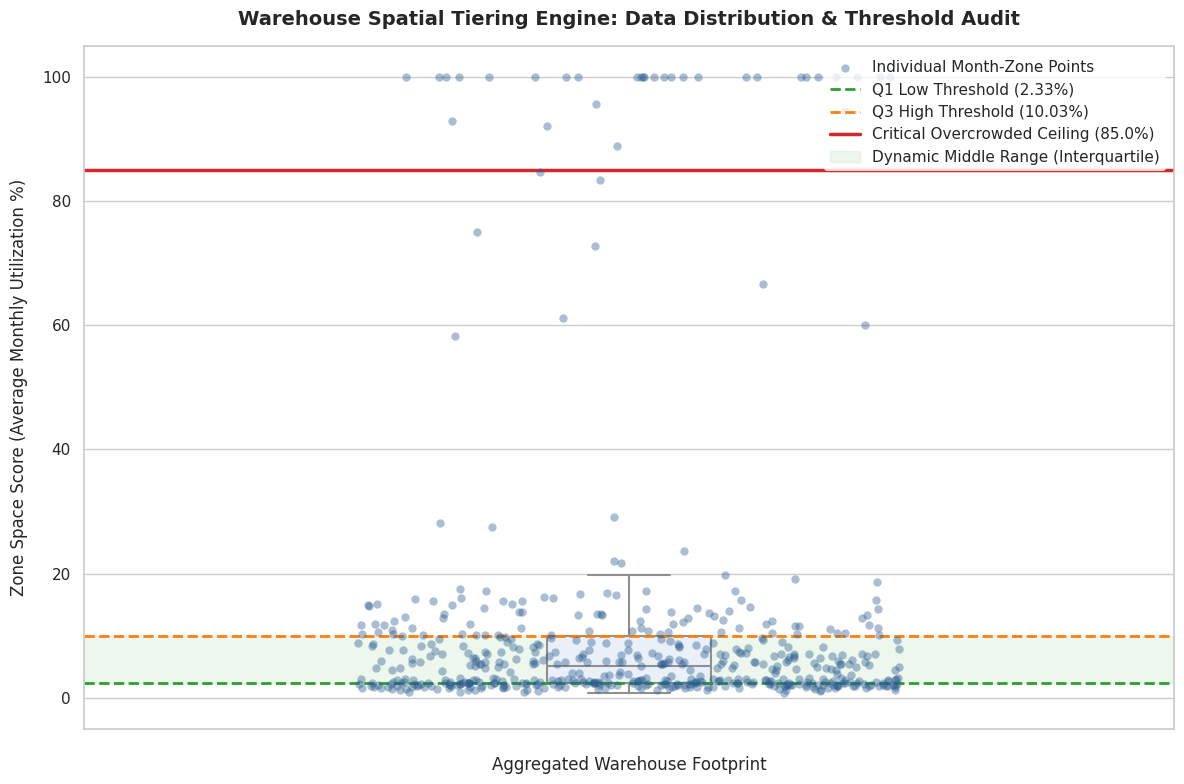

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set clean, professional plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Plot all individual data points with slight horizontal jitter so they don't pile up
sns.stripplot(
    data=zone_space_df, 
    y='Space_Score', 
    color='#2b5c8f', 
    alpha=0.4, 
    size=6, 
    jitter=0.25,
    label='Individual Month-Zone Points'
)

# 2. Add an underlying subtle boxplot to show the mathematical distribution shape
sns.boxplot(
    data=zone_space_df, 
    y='Space_Score', 
    color='#e6f0fa', 
    width=0.15, 
    fliersize=0, 
    linewidth=1.5
)

# 3. Draw the exact Data-Driven Threshold Lines
plt.axhline(y=low_activity_benchmark, color='#2ca02c', linestyle='--', linewidth=2, 
            label=f'Q1 Low Threshold ({low_activity_benchmark:.2f}%)')

plt.axhline(y=high_activity_benchmark, color='#ff7f0e', linestyle='--', linewidth=2, 
            label=f'Q3 High Threshold ({high_activity_benchmark:.2f}%)')

# 4. Draw the Fixed Corporate Physical Constraint Line mandated by your Head
plt.axhline(y=85.0, color='#d62728', linestyle='-', linewidth=2.5, 
            label='Critical Overcrowded Ceiling (85.0%)')

# 5. Shading the "Moderate Activity / Ideal Allocation Zone" (Between Q1 and Q3)
plt.axhspan(low_activity_benchmark, high_activity_benchmark, color='#2ca02c', alpha=0.08, 
            label='Dynamic Middle Range (Interquartile)')

# 6. Formatting Labels, Titles, and Legend for your Presentation
plt.title('Warehouse Spatial Tiering Engine: Data Distribution & Threshold Audit', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Zone Space Score (Average Monthly Utilization %)', fontsize=12, labelpad=10)
plt.xlabel('Aggregated Warehouse Footprint', fontsize=12, labelpad=10)
plt.ylim(-5, 105) # Keeps the percentage scale strictly operational from 0-100%

# Clean up duplicate legend labels caused by mixing seaborn plots
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

5. Machine Utilization

In [13]:
import pandas as pd
import numpy as np

print("--- Parameter 5: Machinery Utilization (Machine-Specific Baselines) ---")

# =====================================================================
# PRE-PROCESSING: Clean the specific equipment IDs
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].astype(str).str.upper()
table1['pickHeNo'] = table1['pickHeNo'].astype(str).str.strip().str.upper()

if not np.issubdtype(table1['pickDate'].dtype, np.datetime64):
    table1['pickDate'] = pd.to_datetime(table1['pickDate'])
table1['pickMonth'] = table1['pickDate'].dt.to_period('M').astype(str)

# =====================================================================
# STEP 1: AGGREGATE TO MONTH-ZONE-EQUIPMENT LAYER
# We use your exact specific machine ID (`pickHeNo`)
# =====================================================================
equip_metrics_df = table1.groupby(['pickMonth', 'storageSectionId', 'pickHeNo']).agg(
    total_picked_units=('pickQty', 'sum'),
    active_time_seconds=('totalTimeSeconds', 'sum')
).reset_index()

# =====================================================================
# STEP 2: APPLY TIME UTILIZATION FORMULAS (Are they turned on?)
# =====================================================================
equip_metrics_df['active_equip_hours'] = equip_metrics_df['active_time_seconds'] / 3600.0

# Time Score = (Active Hours / 260 Total Shift Hours) * 100
equip_metrics_df['Time_Utilization_Score'] = (equip_metrics_df['active_equip_hours'] / 260.0) * 100
equip_metrics_df['Time_Utilization_Score'] = equip_metrics_df['Time_Utilization_Score'].clip(upper=100.0)

# =====================================================================
# STEP 3: CALCULATE EXACT MACHINE BASELINES & RELATIVE EFFICIENCY
# =====================================================================
# 1. Raw speed for this specific machine in this specific zone
equip_metrics_df['Picks_per_Equipment_Hour'] = (
    equip_metrics_df['total_picked_units'] / (equip_metrics_df['active_equip_hours'] + 0.0001)
)

print("--> Calculating Baseline Speeds for each Specific Machine...")
# 2. Group strictly by the exact machine ID to find its personal baseline
global_baselines = equip_metrics_df.groupby('pickHeNo')['Picks_per_Equipment_Hour'].median().reset_index()
global_baselines.rename(columns={'Picks_per_Equipment_Hour': 'Specific_Machine_Baseline'}, inplace=True)

# 3. Merge the specific baseline back
equip_metrics_df = pd.merge(equip_metrics_df, global_baselines, on='pickHeNo', how='left')

# 4. Level Playing Field Ratio (Actual Speed / THIS Machine's Baseline)
equip_metrics_df['Relative_Equipment_Efficiency'] = (
    equip_metrics_df['Picks_per_Equipment_Hour'] / (equip_metrics_df['Specific_Machine_Baseline'] + 0.0001)
) * 100

# =====================================================================
# STEP 4: MACRO ZONE AGGREGATION (Send to ML Model)
# =====================================================================
zone_equipment_summary = equip_metrics_df.groupby(['pickMonth', 'storageSectionId']).agg(
    Zone_Time_Utilization_Score=('Time_Utilization_Score', 'mean'),
    Zone_Equipment_Score=('Relative_Equipment_Efficiency', 'median')
).reset_index()

zone_equipment_summary['Zone_Equipment_Score'] = zone_equipment_summary['Zone_Equipment_Score'].clip(upper=100.0)

# =====================================================================
# STEP 5: OUTPUT PERFORMANCE LOGGING
# =====================================================================
print("\n--- Final Consolidated Equipment Matrix (First 20 Rows) ---")
columns_to_show = ['pickMonth', 'storageSectionId', 'Zone_Time_Utilization_Score', 'Zone_Equipment_Score']
print(zone_equipment_summary[columns_to_show].head(20).to_string(index=False))

print("\n" + "="*65)
print("PARAMETER 5 AUDIT: EQUIPMENT PERFORMANCE SUMMARY")
print("="*65)
print(f"Total Month-Zone configurations analyzed: {len(zone_equipment_summary)} rows")
print(f"Unique Individual Machines Tracked: {table1['pickHeNo'].nunique()}")
print(f"Warehouse-wide avg machine TIME utilization: {zone_equipment_summary['Zone_Time_Utilization_Score'].mean():.2f}%")
print(f"Warehouse-wide avg machine RELATIVE efficiency: {zone_equipment_summary['Zone_Equipment_Score'].mean():.2f}%")

--- Parameter 5: Machinery Utilization (Machine-Specific Baselines) ---
--> Calculating Baseline Speeds for each Specific Machine...

--- Final Consolidated Equipment Matrix (First 20 Rows) ---
pickMonth storageSectionId  Zone_Time_Utilization_Score  Zone_Equipment_Score
  2024-03               AA                     1.311293            100.000000
  2024-03               AB                     0.838251             74.911402
  2024-03               AC                     1.023874             75.508577
  2024-03               AD                     0.659509             62.394876
  2024-03               AE                     1.670358             62.004471
  2024-03               AF                     1.429781             62.814594
  2024-03               AG                     1.204048             65.660965
  2024-03               AH                     1.025977             72.092619
  2024-03               AI                     0.327869            100.000000
  2024-03               AJ

6. Putaway Location Accuracy

In [14]:
print("--- Engineering Parameter 6: Putaway Location Accuracy ---")

# =====================================================================
# 1. STRING CLEANING FOR THE BINS
# =====================================================================
# Ensure text formats match exactly so spaces or lowercase letters don't cause false mismatches
table3['storageBin'] = table3['storageBin'].astype(str).str.upper().str.strip()
table3['proposed_st_bin'] = table3['proposed_st_bin'].astype(str).str.upper().str.strip()

# =====================================================================
# 2. ROW-LEVEL ACCURACY CHECK
# =====================================================================
# If Actual Bin matches Proposed Bin perfectly, assign 1, otherwise 0
table3['is_bin_accurate'] = (table3['storageBin'] == table3['proposed_st_bin']).astype(int)

# =====================================================================
# 3. ZONE-MONTH AGGREGATION
# =====================================================================
# Group by timeline and zone, then calculate the percentage of accurate matches
putaway_accuracy_df = table3.groupby(['putawayMonth', 'storageSectionId']).agg(
    total_putaways=('summary_id', 'size'),
    accurate_putaways=('is_bin_accurate', 'sum')
).reset_index()

# Calculate the final percentage score (0.0 - 100.0)
putaway_accuracy_df['Putaway_Location_Accuracy_Score'] = (
    putaway_accuracy_df['accurate_putaways'] / putaway_accuracy_df['total_putaways']
) * 100

# =====================================================================
# 4. DATA VERIFICATION OUTPUT
# =====================================================================
print("\n--- Putaway Location Accuracy Preview (First 20 Rows) ---")
view_cols = ['putawayMonth', 'storageSectionId', 'total_putaways', 'Putaway_Location_Accuracy_Score']
print(putaway_accuracy_df[view_cols].head(20).to_string(index=False))

print("\n" + "="*60)
print("PARAM 6 STATISTICAL PROFILE")
print("="*60)
print(f"Global Avg Putaway Accuracy: {putaway_accuracy_df['Putaway_Location_Accuracy_Score'].mean():.2f}%")
print(f"Worst Performing Zone Score: {putaway_accuracy_df['Putaway_Location_Accuracy_Score'].min():.2f}%")
print(f"Best Performing Zone Score:  {putaway_accuracy_df['Putaway_Location_Accuracy_Score'].max():.2f}%")
print("-" * 60)

--- Engineering Parameter 6: Putaway Location Accuracy ---

--- Putaway Location Accuracy Preview (First 20 Rows) ---
putawayMonth storageSectionId  total_putaways  Putaway_Location_Accuracy_Score
     2024-03               AA             408                        16.911765
     2024-03               AB             308                         6.818182
     2024-03               AC             513                         4.093567
     2024-03               AD             129                         4.651163
     2024-03               AE             453                         5.518764
     2024-03               AF             426                         3.051643
     2024-03               AG             323                         5.882353
     2024-03               AH             295                         5.084746
     2024-03               AI              61                         3.278689
     2024-03               AJ             303                         1.650165
     2024-03 

7. Dock to Stock Time (Getting Large Values)

In [15]:
# =====================================================================
# PARAMETER: DOCK-TO-STOCK PERFORMANCE SCORE (0.0 - 100.0)
# =====================================================================
print("--- Engineering Parameter: Dock-to-Stock Performance Score ---")

# =====================================================================
# 1. NUMERATOR PREPARATION
# Weight each transaction by how many units were moved
# so a zone moving 500 units in 10 mins outranks one moving 2 units in 10 mins
# =====================================================================
table3['time_qty_product'] = table3['totalTimeinSeconds'] * table3['putAwayQty']

# =====================================================================
# 2. ZONE-MONTH AGGREGATION
# =====================================================================
d2s_macro = table3.groupby(['putawayMonth', 'storageSectionId']).agg(
    sum_time_qty_product=('time_qty_product', 'sum'),
    total_putaway_volume=('putAwayQty', 'sum'),
    total_transactions=('summary_id', 'count')
).reset_index()

# =====================================================================
# 3. WEIGHTED LEAD TIME FORMULA (Your Head's exact formula)
# Result: Average seconds spent per unit putaway in this zone this month
# Lower = faster = better
# =====================================================================
d2s_macro['weighted_d2s_seconds'] = (
    d2s_macro['sum_time_qty_product'] / (d2s_macro['total_putaway_volume'] + 1e-5)
)

# Add this extraction line:
d2s_baseline_seconds = d2s_macro['weighted_d2s_seconds'].median()

# =====================================================================
# 4. RANK-INVERT SCORING WITHIN EACH MONTH
# pct=True gives each zone a rank between 0.0 (fastest) and 1.0 (slowest)
# Inverting means fastest zone scores 100, slowest scores ~0
# This is stable across months — no arbitrary ceiling that shifts monthly
# =====================================================================
d2s_macro['monthly_time_rank'] = d2s_macro.groupby('putawayMonth')['weighted_d2s_seconds'].rank(pct=True)
d2s_macro['Dock_to_Stock_Score'] = (1.0 - d2s_macro['monthly_time_rank']) * 100.0

# =====================================================================
# 5. CLEAN OUTPUT FOR MASTER MATRIX
# =====================================================================
putaway_d2s_df = d2s_macro[['putawayMonth', 'storageSectionId', 'Dock_to_Stock_Score']].copy()

# =====================================================================
# 6. VERIFICATION OUTPUT
# =====================================================================
print("\n--- Dock-to-Stock Score Preview (First 20 Rows) ---")
view_cols = ['putawayMonth', 'storageSectionId', 
             'weighted_d2s_seconds', 'Dock_to_Stock_Score']
print(d2s_macro[view_cols].head(20).to_string(index=False))

print("\n" + "="*60)
print("DOCK-TO-STOCK STATISTICAL PROFILE")
print("="*60)
print(f"Total Zone-Month Records  : {len(d2s_macro)}")
print(f"Global Avg D2S Score      : {d2s_macro['Dock_to_Stock_Score'].mean():.2f}")
print(f"Fastest Zone Score (Max)  : {d2s_macro['Dock_to_Stock_Score'].max():.2f}")
print(f"Slowest Zone Score (Min)  : {d2s_macro['Dock_to_Stock_Score'].min():.2f}")
print(f"Avg Weighted Lead Time    : {d2s_macro['weighted_d2s_seconds'].mean():.0f} seconds")
print("-"*60)

--- Engineering Parameter: Dock-to-Stock Performance Score ---

--- Dock-to-Stock Score Preview (First 20 Rows) ---
putawayMonth storageSectionId  weighted_d2s_seconds  Dock_to_Stock_Score
     2024-03               AA            272.407691            73.913043
     2024-03               AB            650.831309            17.391304
     2024-03               AC            568.763508            21.739130
     2024-03               AD            424.173269            47.826087
     2024-03               AE            439.323843            39.130435
     2024-03               AF            430.502605            43.478261
     2024-03               AG            290.296432            65.217391
     2024-03               AH            547.560366            26.086957
     2024-03               AI            357.452961            52.173913
     2024-03               AJ            447.192550            34.782609
     2024-03               AK            305.021418            60.869565
     202

8. Putaway Throughput

In [16]:
print("--- Engineering Raw Putaway Throughput Parameter ---")

# =====================================================================
# 1. ZONE-MONTH TRANSACTIONAL AGGREGATION
# =====================================================================
# Group by timeline and zone to sum up the pure quantities and pure times
throughput_summary = table3.groupby(['putawayMonth', 'storageSectionId']).agg(
    total_putaway_qty=('putAwayQty', 'sum'),
    total_time_seconds=('totalTimeinSeconds', 'sum')
).reset_index()

# =====================================================================
# 2. THE CHIEF'S LINEAR FORMULA: Σ(qty) ÷ Σ(time)
# =====================================================================
# Adding 1e-5 to prevent any accidental division-by-zero errors
throughput_summary['raw_throughput_rate'] = (
    throughput_summary['total_putaway_qty'] / (throughput_summary['total_time_seconds'] + 1e-5)
)

# =====================================================================
# 3. ROBUST SCALING LAYER — Percentile Ceiling Instead of Max
# =====================================================================
# Using max (or 95th percentile of all zones) means one outlier zone
# like RE drags everyone else to near zero.
# Instead, use the 75th percentile as the "excellent" benchmark.
# Zones above it get capped at 100, zones below scale naturally.
# =====================================================================

monthly_throughput_ceilings = (
    throughput_summary.groupby('putawayMonth')['raw_throughput_rate']
    .quantile(0.75)
    .reset_index()
    .rename(columns={'raw_throughput_rate': 'throughput_ceiling'})
)

# Add this extraction line:
putaway_75th_ceiling_global = monthly_throughput_ceilings['throughput_ceiling'].median()

throughput_summary = throughput_summary.merge(
    monthly_throughput_ceilings, on='putawayMonth', how='left'
)

throughput_summary['Putaway_Throughput_Score'] = (
    throughput_summary['raw_throughput_rate'] / 
    (throughput_summary['throughput_ceiling'] + 1e-5)
) * 100

# Zones faster than the 75th percentile naturally score above 100 — cap them
throughput_summary['Putaway_Throughput_Score'] = (
    throughput_summary['Putaway_Throughput_Score'].clip(upper=100.0)
)

# =====================================================================
# 4. OUTPUT PREVIEW FOR DIAGNOSIS
# =====================================================================
print("\n--- Putaway Throughput Score Preview (First 20 Rows) ---")
view_cols = ['putawayMonth', 'storageSectionId', 'total_putaway_qty', 'total_time_seconds', 'raw_throughput_rate', 'Putaway_Throughput_Score']
print(throughput_summary[view_cols].head(20).to_string(index=False))

--- Engineering Raw Putaway Throughput Parameter ---

--- Putaway Throughput Score Preview (First 20 Rows) ---
putawayMonth storageSectionId  total_putaway_qty  total_time_seconds  raw_throughput_rate  Putaway_Throughput_Score
     2024-03               AA             1950.0            176396.0             0.011055                 94.802065
     2024-03               AB             1156.0            177498.0             0.006513                 55.851686
     2024-03               AC             1036.0            243873.0             0.004248                 36.430737
     2024-03               AD              479.0             54254.0             0.008829                 75.713909
     2024-03               AE             1019.0            229832.0             0.004434                 38.022057
     2024-03               AF             1534.0            187780.0             0.008169                 70.056420
     2024-03               AG             1346.0            110136.0         

9. Median Drop Size

In [17]:
# # =====================================================================
# # PARAMETER: MEDIAN DROP SIZE PROFILE
# # Separates Bulk Receiving Zones from Single Unit Receiving Zones
# # Directly supports slotting by matching item types to zone profiles
# # =====================================================================
# print("--- Engineering Parameter: Zone Drop Size Profile ---")

# Use_Count = False
# table3['storageSectionId'] = table3['storageSectionId'].str.upper().str.strip()

# if Use_Count:
#     table3['effective_drop_qty'] = table3['count'] * table3['putAwayQty']
#     qty_label = "count × putAwayQty"
# else:
#     table3['effective_drop_qty'] = table3['putAwayQty']
#     qty_label = "putAwayQty"

# print(f"Mode: {qty_label}")

# zone_drop_df = table3.groupby(['putawayMonth', 'storageSectionId']).agg(
#     median_drop_size=('effective_drop_qty', 'median'),
#     mean_drop_size=('effective_drop_qty', 'mean'),
#     total_transactions=('effective_drop_qty', 'count'),
#     total_putaway_qty=('effective_drop_qty', 'sum')
# ).reset_index()

# zone_drop_df['mean_median_ratio'] = (
#     zone_drop_df['mean_drop_size'] / (zone_drop_df['median_drop_size'] + 0.001)
# )

# skew_flag_threshold = 5.0
# zone_drop_df['Bulk_Spike_Flag'] = zone_drop_df['mean_median_ratio'] > skew_flag_threshold

# best_drop_df = zone_drop_df.groupby('putawayMonth')['median_drop_size'].max().reset_index()
# best_drop_df.rename(columns={'median_drop_size': 'best_median_drop'}, inplace=True)
# zone_drop_df = pd.merge(zone_drop_df, best_drop_df, on='putawayMonth', how='left')

# zone_drop_df['Avg_Drop_Size_Score'] = (
#     zone_drop_df['median_drop_size'] / (zone_drop_df['best_median_drop'] + 0.001)
# ) * 100

# q3_benchmark = zone_drop_df['Avg_Drop_Size_Score'].quantile(0.75)
# q1_benchmark = zone_drop_df['Avg_Drop_Size_Score'].quantile(0.25)

# if q1_benchmark == q3_benchmark:
#     q1_benchmark = zone_drop_df['Avg_Drop_Size_Score'].median() * 0.5

# def classify_drop_profile(score, q3_limit, q1_limit):
#     if score >= q3_limit:
#         return 'Bulk-Profile Zone'
#     elif score >= q1_limit:
#         return 'Standard-Profile Zone'
#     else:
#         return 'Micro-Drop Zone'

# zone_drop_df['Drop_Profile'] = zone_drop_df['Avg_Drop_Size_Score'].apply(
#     lambda x: classify_drop_profile(x, q3_benchmark, q1_benchmark)
# )

# print(f"\nWarehouse-Wide Median Drop Size Baseline : {zone_drop_df['median_drop_size'].median():.2f} units/transaction")
# print(f"Calculated Q3 Bulk-Profile Benchmark     : {q3_benchmark:.2f}")
# print(f"Calculated Q1 Micro-Drop Benchmark       : {q1_benchmark:.2f}")

# total_zone_months = len(zone_drop_df)
# bulk_count = len(zone_drop_df[zone_drop_df['Drop_Profile'] == 'Bulk-Profile Zone'])
# standard_count = len(zone_drop_df[zone_drop_df['Drop_Profile'] == 'Standard-Profile Zone'])
# micro_count = len(zone_drop_df[zone_drop_df['Drop_Profile'] == 'Micro-Drop Zone'])
# spike_count = zone_drop_df['Bulk_Spike_Flag'].sum()

# print("\n" + "="*60)
# print("PARAMETER AUDIT: ZONE DROP SIZE PROFILE REPORT")
# print("="*60)
# print(f"Total Zone-Month records processed       : {total_zone_months}")
# print(f"Bulk-Profile Zones  (>= Q3 {q3_benchmark:.2f})     : {bulk_count} rows")
# print(f"Standard-Profile Zones (Q1 to Q3)        : {standard_count} rows")
# print(f"Micro-Drop Zones    (< Q1 {q1_benchmark:.2f})      : {micro_count} rows")
# print(f"Bulk Spike Warnings (mean/median > {skew_flag_threshold}) : {spike_count} rows")
# print("\n--- Preview (First 20 Rows) ---")
# view_cols = ['putawayMonth', 'storageSectionId', 'median_drop_size',
#              'Avg_Drop_Size_Score', 'Drop_Profile', 'Bulk_Spike_Flag']
# print(zone_drop_df[view_cols].head(20).to_string(index=False))

Combining all 8 parameters

In [18]:
# =====================================================================
# PHASE 1: UNIFYING 8 PARAMETERS INTO MASTER OPERATIONAL MATRIX
# =====================================================================
print("--- Compiling 8-Parameter Master Zone Matrix ---")

# 1. BASELINE MAP & PARAMETER 1 (Outbound Throughput Score)
zt_macro = table1.groupby(['pickMonth', 'storageSectionId']).agg(
    zone_units=('pickQty', 'sum'),
    zone_time=('totalTimeSeconds', 'sum')
).reset_index()

zt_macro['zone_throughput'] = zt_macro['zone_units'] / (zt_macro['zone_time'] + 0.001)
# Replace max() with 95th percentile ceiling
zt_best = zt_macro.groupby('pickMonth')['zone_throughput'].quantile(0.95).reset_index()
zt_best.rename(columns={'zone_throughput': 'best_throughput'}, inplace=True)

throughput_95th_ceiling_global = zt_best['best_throughput'].median()

zt_macro = zt_macro.merge(zt_best, on='pickMonth', how='left')
zt_macro['Zone_Throughput_Score'] = (zt_macro['zone_throughput'] / zt_macro['best_throughput']) * 100
zt_macro['Zone_Throughput_Score'] = zt_macro['Zone_Throughput_Score'].clip(upper=100.0)

# Initialize the master matrix with your core keys and Parameter 1
master_zone_df = zt_macro[['pickMonth', 'storageSectionId', 'Zone_Throughput_Score']].copy()
master_zone_df['pickMonth'] = master_zone_df['pickMonth'].astype(str)


# 2. ISOLATE REMAINING PARAMETER DATASETS
# --- Outbound Parameters ---
df_pick_rate = zone_pick_rate_df[['pickMonth', 'storageSectionId', 'Zone_Pick_Rate_Score']].copy()
df_pick_rate['pickMonth'] = df_pick_rate['pickMonth'].astype(str)

df_picker_perf = zone_picker_scores_df[['pickMonth', 'storageSectionId', 'Zone_Picker_Performance_Score']].copy()
df_picker_perf['pickMonth'] = df_picker_perf['pickMonth'].astype(str)

df_equipment = zone_equipment_summary[['pickMonth', 'storageSectionId', 'Zone_Equipment_Score']].copy()
df_equipment['pickMonth'] = df_equipment['pickMonth'].astype(str) # FIX: Fixed the NameError typo here

# --- Structural/Space Parameters ---
df_space = zone_space_df[['spaceMonth', 'st_sec_id', 'Space_Score']].copy()
df_space.rename(columns={'spaceMonth': 'pickMonth', 'st_sec_id': 'storageSectionId'}, inplace=True)
df_space['pickMonth'] = df_space['pickMonth'].astype(str)

# --- Inbound Parameters ---
df_putaway_thru = throughput_summary[['putawayMonth', 'storageSectionId', 'Putaway_Throughput_Score']].copy()
df_putaway_thru['putawayMonth'] = df_putaway_thru['putawayMonth'].astype(str)
df_putaway_thru.rename(columns={'putawayMonth': 'pickMonth'}, inplace=True)

df_d2s = putaway_d2s_df[['putawayMonth', 'storageSectionId', 'Dock_to_Stock_Score']].copy()
df_d2s['putawayMonth'] = df_d2s['putawayMonth'].astype(str)
df_d2s.rename(columns={'putawayMonth': 'pickMonth'}, inplace=True)

df_accuracy = putaway_accuracy_df[['putawayMonth', 'storageSectionId', 'Putaway_Location_Accuracy_Score']].copy()
df_accuracy['putawayMonth'] = df_accuracy['putawayMonth'].astype(str)
df_accuracy.rename(columns={'putawayMonth': 'pickMonth'}, inplace=True)


# 3. SEQUENTIAL LEFT-MERGE LAYER
master_zone_df = master_zone_df.merge(df_pick_rate, on=['pickMonth', 'storageSectionId'], how='left')
master_zone_df = master_zone_df.merge(df_picker_perf, on=['pickMonth', 'storageSectionId'], how='left')
master_zone_df = master_zone_df.merge(df_space, on=['pickMonth', 'storageSectionId'], how='left')
master_zone_df = master_zone_df.merge(df_equipment, on=['pickMonth', 'storageSectionId'], how='left')
master_zone_df = master_zone_df.merge(df_putaway_thru, on=['pickMonth', 'storageSectionId'], how='left')
master_zone_df = master_zone_df.merge(df_d2s, on=['pickMonth', 'storageSectionId'], how='left')
master_zone_df = master_zone_df.merge(df_accuracy, on=['pickMonth', 'storageSectionId'], how='left')


# 4. ROBUST OPERATIONAL IMPUTATION LAYER
features_to_cluster = [
    'Zone_Pick_Rate_Score', 'Zone_Throughput_Score', 'Zone_Picker_Performance_Score', 
    'Space_Score', 'Zone_Equipment_Score', 'Putaway_Throughput_Score', 
    'Dock_to_Stock_Score', 'Putaway_Location_Accuracy_Score'
]

# Impute localized missing records using that specific zone's historical medians
for col in features_to_cluster:
    master_zone_df[col] = master_zone_df.groupby('storageSectionId')[col].transform(lambda x: x.fillna(x.median()))

# Universal backup fallback
master_zone_df.fillna(master_zone_df.median(numeric_only=True), inplace=True)
master_zone_df.reset_index(drop=True, inplace=True)


# 5. DATA PREVIEW VERIFICATION
print(f"Success! 8-Parameter Master Zone Matrix Compiled: {master_zone_df.shape[0]} rows.")
print("\n--- Summary Verification: Null Value Check (Should be all 0) ---")
print(master_zone_df[features_to_cluster].isnull().sum())
print("\n--- Master Operational Matrix Preview (First 10 Rows) ---")
print(master_zone_df[['pickMonth', 'storageSectionId'] + features_to_cluster].head(10).to_string(index=False))

--- Compiling 8-Parameter Master Zone Matrix ---
Success! 8-Parameter Master Zone Matrix Compiled: 523 rows.

--- Summary Verification: Null Value Check (Should be all 0) ---
Zone_Pick_Rate_Score               0
Zone_Throughput_Score              0
Zone_Picker_Performance_Score      0
Space_Score                        0
Zone_Equipment_Score               0
Putaway_Throughput_Score           0
Dock_to_Stock_Score                0
Putaway_Location_Accuracy_Score    0
dtype: int64

--- Master Operational Matrix Preview (First 10 Rows) ---
pickMonth storageSectionId  Zone_Pick_Rate_Score  Zone_Throughput_Score  Zone_Picker_Performance_Score  Space_Score  Zone_Equipment_Score  Putaway_Throughput_Score  Dock_to_Stock_Score  Putaway_Location_Accuracy_Score
  2024-03               AA             62.122422              21.989267                      63.320262     2.985667            100.000000                 94.802065            73.913043                        16.911765
  2024-03            

CRITIC + Weighted K-Means Method:

In [19]:
# =====================================================================
# PHASE 2: PURE DYNAMIC CRITIC WEIGHTING & K-MEANS CLUSTERING
# =====================================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

print("--- Initializing Pure CRITIC + K-Means Engine ---")

features_to_cluster = [
    'Zone_Pick_Rate_Score', 'Zone_Throughput_Score', 'Zone_Picker_Performance_Score', 
    'Space_Score', 'Zone_Equipment_Score', 'Putaway_Throughput_Score', 
    'Dock_to_Stock_Score', 'Putaway_Location_Accuracy_Score'
]

# =====================================================================
# 1. STRICT SCALING (0.0 to 1.0)
# =====================================================================
scaler_business = MinMaxScaler(feature_range=(0, 1))
X_scaled_strict = scaler_business.fit_transform(master_zone_df[features_to_cluster])
scaled_df = pd.DataFrame(X_scaled_strict, columns=features_to_cluster)

# =====================================================================
# 2. 100% DYNAMIC CRITIC WEIGHTING (No Manual Overrides)
# =====================================================================
# Step A: Calculate Contrast (Standard Deviation)
std_dev = scaled_df.std()

# Step B: Calculate Conflict (Correlation Matrix Inversion)
corr_matrix = scaled_df.corr().fillna(0)
conflict = (1 - corr_matrix).sum(axis=1)

# Step C: Calculate the Information Quantity (Contrast * Conflict)
information_quantity = std_dev * conflict

# Step D: Normalize into 100% dynamic weights
dynamic_weights = information_quantity / information_quantity.sum()
business_weights = dynamic_weights.values

print("\n--- PURE CRITIC WEIGHTS GENERATED ---")
for col, weight in zip(features_to_cluster, business_weights):
    print(f"{col}: {weight*100:.2f}%")
print("=======================================\n")

# Apply weights using Square Root Euclidean stretch
X_weighted = X_scaled_strict * np.sqrt(business_weights)

# =====================================================================
# 3. K-MEANS TRAINING (3-Tier Operational Segmentation)
# =====================================================================
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
master_zone_df['Zone_Cluster_Label'] = kmeans.fit_predict(X_weighted)

# Rank the clusters by their composite center scores to assign Tiers natively
cluster_composite_scores = kmeans.cluster_centers_.mean(axis=1)
sorted_clusters = np.argsort(cluster_composite_scores)

cluster_mapping = {
    sorted_clusters[2]: 'Tier 1: High Efficiency',
    sorted_clusters[1]: 'Tier 2: Moderate Efficiency',
    sorted_clusters[0]: 'Tier 3: Low Efficiency'
}

print("K-Means 8-Parameter Clustering Successful!")

# =====================================================================
# 4. PIECEWISE GEOMETRIC SCORING LAYER (0.0 - 100.0 Output)
# =====================================================================
distances = kmeans.transform(X_weighted)

inverted_map = {v: k for k, v in cluster_mapping.items()}
tier1_idx = inverted_map['Tier 1: High Efficiency']
tier2_idx = inverted_map['Tier 2: Moderate Efficiency']
tier3_idx = inverted_map['Tier 3: Low Efficiency']

synchronized_scores = []
synchronized_tiers = []

for enum_i, (i, row) in enumerate(master_zone_df.iterrows()):
    assigned_cluster = row['Zone_Cluster_Label']
    
    # 1. Pull Core Outbound AND Inbound Metrics
    current_pick_rate = row['Zone_Pick_Rate_Score']
    current_outbound_thru = row['Zone_Throughput_Score']
    
    current_d2s = row['Dock_to_Stock_Score']
    current_putaway_thru = row['Putaway_Throughput_Score']
    
    # 2. UPDATED ABSOLUTE FLOOR (True Zombie Zone)
    # Both Outbound AND Inbound must be dead to instantly fail it
    if (current_pick_rate <= 5.0 and current_outbound_thru <= 5.0) and \
       (current_d2s <= 10.0 and current_putaway_thru <= 10.0):
        synchronized_scores.append(0.0)
        synchronized_tiers.append(cluster_mapping[tier3_idx])
        continue
        
    # 3. UPDATED ABSOLUTE CEILING (Perfect World Zone)
    # Both Outbound AND Inbound must be elite to instantly max it
    if (current_pick_rate >= 82.0 and current_outbound_thru >= 89.0) and \
       (current_d2s >= 85.0 and current_putaway_thru >= 85.0):
        synchronized_scores.append(100.0)
        synchronized_tiers.append(cluster_mapping[tier1_idx])
        continue
        
    d1 = distances[enum_i, tier1_idx]
    d2 = distances[enum_i, tier2_idx]
    d3 = distances[enum_i, tier3_idx]
    
    if assigned_cluster == tier3_idx:
        score = 33.33 * (1 - (d3 / (d3 + d2 + 1e-5)))
    elif assigned_cluster == tier2_idx:
        if d3 < d1:
            score = 33.33 + (16.67 * (d3 / (d2 + d3 + 1e-5)))
        else:
            score = 50.00 + (16.66 * (1 - (d2 / (d1 + d2 + 1e-5))))
    else:
        score = 66.66 + (33.34 * (d2 / (d1 + d2 + 1e-5)))
        
    synchronized_scores.append(score)
    synchronized_tiers.append(cluster_mapping[assigned_cluster])

master_zone_df['Zone_Efficiency_Score'] = synchronized_scores
master_zone_df['Zone_Efficiency_Tier'] = synchronized_tiers

# =====================================================================
# 5. PRINT COMPLETE WAREHOUSE SUMMARY REPORT CARD
# =====================================================================
print("\nFINAL 8-PARAMETER ZONE EFFICIENCY SEGMENTATION SUMMARY")
print("-" * 55)
print(master_zone_df['Zone_Efficiency_Tier'].value_counts().to_string())
print("-" * 55)

--- Initializing Pure CRITIC + K-Means Engine ---

--- PURE CRITIC WEIGHTS GENERATED ---
Zone_Pick_Rate_Score: 7.36%
Zone_Throughput_Score: 11.99%
Zone_Picker_Performance_Score: 8.38%
Space_Score: 15.20%
Zone_Equipment_Score: 8.03%
Putaway_Throughput_Score: 16.62%
Dock_to_Stock_Score: 16.77%
Putaway_Location_Accuracy_Score: 15.65%

K-Means 8-Parameter Clustering Successful!

FINAL 8-PARAMETER ZONE EFFICIENCY SEGMENTATION SUMMARY
-------------------------------------------------------
Zone_Efficiency_Tier
Tier 3: Low Efficiency         275
Tier 1: High Efficiency        208
Tier 2: Moderate Efficiency     40
-------------------------------------------------------


In [20]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.decomposition import PCA

# # =====================================================================
# # 1. CORRECTED DIMENSIONALITY REDUCTION FOR WEIGHTED K-MEANS
# # =====================================================================
# # Instead of fitting PCA directly on the skewed data, we fit it on the 
# # strictly scaled data but pass the weights to give PCA the correct orientation.
# pca = PCA(n_components=2)

# # Fit PCA on the scaled data so the geometric dimensions stay uniform
# pca.fit(X_scaled_strict)

# # Transform the actual weighted data that K-Means used into this balanced 2D space
# pca_components = pca.transform(X_weighted)

# # Add the clean 2D coordinates back to the DataFrame for plotting
# master_zone_df['PCA_X'] = pca_components[:, 0]
# master_zone_df['PCA_Y'] = pca_components[:, 1]

# # Squash the 3 Centroids down using the exact same transformation matrix
# centroids_2d = pca.transform(kmeans.cluster_centers_)

# # =====================================================================
# # 2. DEFINING THE CLUSTER TO STRING STRATIFICATION
# # =====================================================================
# # Rank the clusters by their composite center scores to assign Tiers natively
# # (This ensures 'Tier 1' is always mathematically assigned to the highest center)
# cluster_composite_scores = kmeans.cluster_centers_.mean(axis=1)
# sorted_clusters = np.argsort(cluster_composite_scores)

# plot_cluster_mapping = {
#     sorted_clusters[2]: 'Tier 1: High Efficiency',
#     sorted_clusters[1]: 'Tier 2: Moderate Efficiency',
#     sorted_clusters[0]: 'Tier 3: Low Efficiency'
# }

# # Explicitly map the raw, untouched K-Means cluster numbers to the clean string names
# master_zone_df['Raw_KMeans_Tier'] = master_zone_df['Zone_Cluster_Label'].map(plot_cluster_mapping)

# # =====================================================================
# # 3. PLOT SETUP & CORPORATE STYLING
# # =====================================================================
# plt.figure(figsize=(12, 8))
# sns.set_theme(style="whitegrid")

# # Define strict corporate colors for the tiers (Green, Orange, Red)
# tier_colors = {
#     'Tier 1: High Efficiency': '#2ca02c',  
#     'Tier 2: Moderate Efficiency': '#ff7f0e',  
#     'Tier 3: Low Efficiency': '#d62728'   
# }

# # =====================================================================
# # 4. DRAW THE CLUSTER MAP
# # =====================================================================
# # Draw all the individual warehouse zones colored by their RAW ML assignment
# sns.scatterplot(
#     data=master_zone_df,
#     x='PCA_X',
#     y='PCA_Y',
#     hue='Raw_KMeans_Tier',
#     palette=tier_colors,
#     alpha=0.75,
#     s=100,
#     edgecolor='black',
#     linewidth=0.5,
#     hue_order=['Tier 1: High Efficiency', 'Tier 2: Moderate Efficiency', 'Tier 3: Low Efficiency']
# )

# # Draw the 3 Centroids (The "Gravity Centers" of the tiers)
# plt.scatter(
#     centroids_2d[:, 0], 
#     centroids_2d[:, 1], 
#     c='black', 
#     s=400, 
#     marker='X', 
#     linewidths=2.5,
#     label='Mathematical Centroids (Target Centers)'
# )

# # =====================================================================
# # 5. FORMATTING & LABELS
# # =====================================================================
# variance_explained = pca.explained_variance_ratio_.sum() * 100

# plt.title('Warehouse Zone Topography: Weighted K-Means Efficiency Clusters', fontsize=16, fontweight='bold', pad=15)
# plt.xlabel(f'Primary Performance Axis (Variance Explained: {pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
# plt.ylabel(f'Secondary Performance Axis (Variance Explained: {pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')

# # Move the legend outside the plot so it doesn't cover data points
# plt.legend(title='Operational Stratification', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=12)

# # Strategic footprint note tracking data variance
# plt.text(0.5, -0.15, f'*Note: Map represents a 2D projection of an 8-dimensional weighted feature space capturing {variance_explained:.1f}% of total data variance.', 
#          ha='center', va='center', transform=plt.gca().transAxes, fontsize=10, fontstyle='italic', color='gray')

# plt.tight_layout()
# plt.show()

Comparison of models

In [21]:
# import matplotlib.pyplot as plt

# # =====================================================================
# # 1. WEIGHTED LINEAR MATH MODEL (Apples-to-Apples Baseline)
# # =====================================================================
# scaler_linear = MinMaxScaler(feature_range=(0, 100))
# linear_scaled = scaler_linear.fit_transform(master_zone_df[features_to_cluster])

# # THE FIX: Replace .mean() with np.dot() to apply the exact same business percentages
# master_zone_df['Linear_Score'] = np.dot(linear_scaled, business_weights)

# # =====================================================================
# # 2. UNGATED WEIGHTED K-MEANS (Testing the ML without Safety Gates)
# # =====================================================================
# ungated_scores = []

# # THE FIX: Added enumerate and enum_i
# for enum_i, (i, row) in enumerate(master_zone_df.iterrows()):
#     assigned_cluster = row['Zone_Cluster_Label']
    
#     # THE FIX: Safely pull from distances using enum_i
#     d1 = distances[enum_i, tier1_idx]
#     d2 = distances[enum_i, tier2_idx]
#     d3 = distances[enum_i, tier3_idx]
    
#     if assigned_cluster == tier3_idx:
#         score = 33.33 * (1 - (d3 / (d3 + d2 + 1e-5)))
#     elif assigned_cluster == tier2_idx:
#         if d3 < d1:
#             score = 33.33 + (16.67 * (d3 / (d2 + d3 + 1e-5)))
#         else:
#             score = 50.00 + (16.66 * (1 - (d2 / (d1 + d2 + 1e-5))))
#     else:
#         score = 66.66 + (33.34 * (d2 / (d1 + d2 + 1e-5)))
#     ungated_scores.append(score)
    
# master_zone_df['Ungated_KMeans_Score'] = ungated_scores

# # =====================================================================
# # 3. BUILD ZOMBIE ZONE & APPLY BUSINESS WEIGHTS
# # =====================================================================
# # Ensure this dictionary exactly matches your 5 surviving parameters
# zombie_features = {
#     # The Core Failures (Outbound and Inbound are dead on a 0-100 scale)
#     'Zone_Pick_Rate_Score': 2.0,            
#     'Zone_Throughput_Score': 2.0,           
#     'Putaway_Throughput_Score': 4.0,        
#     'Dock_to_Stock_Score': 4.0,             
    
#     # The "Trap" Metrics (Artificially High, properly scaled)
#     'Space_Score': 4.9,                     # Max physical space score is ~5.0
#     'Zone_Equipment_Score': 3.0,            # Max physical equipment score is ~3.0
#     'Putaway_Location_Accuracy_Score': 99.0,# 0-100 scale
#     'Zone_Picker_Performance_Score': 85.0   # 0-100 scale
# }

# # Convert to DataFrame
# zombie_df = pd.DataFrame([zombie_features])

# # Score zombie through WEIGHTED LINEAR MODEL
# # This will now work perfectly because all 8 columns match features_to_cluster!
# zombie_linear_scaled = scaler_linear.transform(zombie_df[features_to_cluster])
# zombie_linear_score = np.dot(zombie_linear_scaled, business_weights)[0]

# # Score zombie through UNGATED WEIGHTED K-MEANS
# # THE FIX: Use the new business variables!
# zombie_scaled_strict = scaler_business.transform(zombie_df[features_to_cluster])
# zombie_weighted = zombie_scaled_strict * np.sqrt(business_weights)

# zombie_cluster = kmeans.predict(zombie_weighted)[0]
# zombie_distances = kmeans.transform(zombie_weighted)[0]

# zd1, zd2, zd3 = zombie_distances[tier1_idx], zombie_distances[tier2_idx], zombie_distances[tier3_idx]

# if zombie_cluster == tier3_idx:
#     zombie_ungated = 33.33 * (1 - (zd3 / (zd3 + zd2 + 1e-5)))
# elif zombie_cluster == tier2_idx:
#     if zd3 < zd1:
#         zombie_ungated = 33.33 + (16.67 * (zd3 / (zd2 + zd3 + 1e-5)))
#     else:
#         zombie_ungated = 50.00 + (16.66 * (1 - (zd2 / (zd1 + zd2 + 1e-5))))
# else:
#     zombie_ungated = 66.66 + (33.34 * (zd2 / (zd1 + zd2 + 1e-5)))

# # Score zombie through HYBRID MODEL
# zombie_hybrid = 0.0  # Gate fires naturally

# # =====================================================================
# # 4. SELECT REAL ZONES FOR CHART
# # =====================================================================
# best_zone = master_zone_df.loc[master_zone_df['Zone_Efficiency_Score'].idxmax()].copy()
# tier2_zones = master_zone_df[master_zone_df['Zone_Efficiency_Tier'] == 'Tier 2: Moderate Efficiency']
# avg_zone = tier2_zones.iloc[len(tier2_zones) // 2].copy()
# worst_zone = master_zone_df.loc[master_zone_df['Zone_Efficiency_Score'].idxmin()].copy()

# plot_data = pd.DataFrame([
#     {
#         'Label': f"Real Best Zone\n({best_zone['storageSectionId']})",
#         'Linear_Score': best_zone['Linear_Score'],
#         'Ungated_KMeans_Score': best_zone['Ungated_KMeans_Score'],
#         'Hybrid_Score': best_zone['Zone_Efficiency_Score']
#     },
#     {
#         'Label': f"Real Average Zone\n({avg_zone['storageSectionId']})",
#         'Linear_Score': avg_zone['Linear_Score'],
#         'Ungated_KMeans_Score': avg_zone['Ungated_KMeans_Score'],
#         'Hybrid_Score': avg_zone['Zone_Efficiency_Score']
#     },
#     {
#         'Label': "Zombie Zone\n(Broken Aisle, System Test)",
#         'Linear_Score': zombie_linear_score,
#         'Ungated_KMeans_Score': zombie_ungated,
#         'Hybrid_Score': zombie_hybrid
#     },
#     {
#         'Label': f"Real Worst Zone\n({worst_zone['storageSectionId']})",
#         'Linear_Score': worst_zone['Linear_Score'],
#         'Ungated_KMeans_Score': worst_zone['Ungated_KMeans_Score'],
#         'Hybrid_Score': worst_zone['Zone_Efficiency_Score']
#     }
# ])

# # =====================================================================
# # 5. PLOT CHART
# # =====================================================================
# fig, ax = plt.subplots(figsize=(11, 6))
# x = np.arange(len(plot_data))
# width = 0.25

# rects1 = ax.bar(x - width, plot_data['Linear_Score'], width, label='Pure Linear Weighted Math Model', color='#A0A0A0')
# rects2 = ax.bar(x, plot_data['Ungated_KMeans_Score'], width, label='Ungated Weighted K-Means', color='#1F77B4')
# rects3 = ax.bar(x + width, plot_data['Hybrid_Score'], width, label='Our Entropy Hybrid (Deployed)', color='#2CA02C')

# ax.set_ylabel('Efficiency Score (0 - 100)', fontweight='bold', fontsize=12)
# ax.set_title('Real Warehouse Architecture Validation & Stress Test', fontweight='bold', fontsize=14, pad=15)
# ax.set_xticks(x)
# ax.set_xticklabels(plot_data['Label'], fontweight='bold', fontsize=10)
# ax.set_ylim(0, 115)
# ax.grid(axis='y', linestyle='--', alpha=0.5)
# ax.legend(loc='upper right', frameon=True, shadow=True)

# for rects in [rects1, rects2, rects3]:
#     for rect in rects:
#         height = rect.get_height()
#         ax.annotate(f'{height:.1f}',
#                     xy=(rect.get_x() + rect.get_width() / 2, height),
#                     xytext=(0, 3), textcoords='offset points',
#                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# ax.annotate('CRITICAL FAILURE:\nLinear Math & Un-gated ML\ngive a passing score to a\nsimulated broken aisle!',
#             xy=(2, zombie_ungated), xytext=(2.65, 68),
#             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6),
#             ha='center', fontweight='bold', color='red',
#             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='red', lw=1.5))

# plt.tight_layout()
# plt.show()

GROUP AHP Weights

In [22]:
# =====================================================================
# PHASE 1: GROUP AHP & CONSISTENCY EXTRACTION ENGINE
# =====================================================================
import pandas as pd
import numpy as np

print("--- Initializing Group AHP Strategy Engine ---")

def extract_ahp_matrix_from_excel(excel_path, sheet_name):
    # 1. Read the Excel sheet natively
    df = pd.read_excel(excel_path, sheet_name=sheet_name, engine='openpyxl')
    
    # 2. Extract the engineering parameter names from the correct row
    param_names = df.iloc[1, 2:10].values.tolist()
    
    # 3. Isolate the core 8x8 pairwise matrix grid
    matrix_grid = df.iloc[2:10, 2:10].copy()
    matrix_grid.index = param_names
    matrix_grid.columns = param_names
    
    # 4. Parser to convert text fractions ('1/3') or weird types safely to floats
    def parse_to_float(value):
        if pd.isna(value):
            return 1.0  # Default diagonal assignment
        val_str = str(value).strip()
        if '/' in val_str:
            num, denom = val_str.split('/')
            return float(num) / float(denom)
        return float(val_str)

    # 5. Version-proof element mapping
    if hasattr(matrix_grid, 'map'):
        cleaned_matrix = matrix_grid.map(parse_to_float)
    else:
        cleaned_matrix = matrix_grid.applymap(parse_to_float)
        
    return cleaned_matrix

# =====================================================================
# 1. RUN THE EXTRACTION FOR BOTH EXPERTS
# =====================================================================
excel_path = "/home/adityaa/Desktop/internship/Group AHP Scores.xlsx"

# Make sure the sheet_name matches exactly what is in your Excel file
matrix_1_df = extract_ahp_matrix_from_excel(excel_path, sheet_name="Matrix_1")
matrix_2_df = extract_ahp_matrix_from_excel(excel_path, sheet_name="Matrix_2") # Change this if the second sheet is named differently!

# Convert the DataFrames to pure mathematical Numpy arrays
head_matrix = matrix_1_df.values
senior_matrix = matrix_2_df.values

# Extract dynamic features and matrix size
ahp_features = matrix_1_df.columns.tolist()
n = len(ahp_features)

# =====================================================================
# 2. CALCULATE GROUP CONSENSUS (GEOMETRIC MEAN)
# =====================================================================
# Because there are 2 experts, we take the square root of their product.
consensus_matrix = np.sqrt(head_matrix * senior_matrix)

# =====================================================================
# 3. CALCULATE PRIORITY VECTOR (THE EXPERT WEIGHTS)
# =====================================================================
# Step A: Normalize the consensus matrix by dividing by column sums
col_sums = consensus_matrix.sum(axis=0)
normalized_matrix = consensus_matrix / col_sums

# Step B: Calculate the row averages to get the final weights
ahp_weights = normalized_matrix.mean(axis=1)

# =====================================================================
# 4. CONSISTENCY RATIO (CR) CHECK
# =====================================================================
# Standard Random Index (RI) values for n=1 to 10
RI_dict = {1:0.0, 2:0.0, 3:0.58, 4:0.90, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45, 10:1.49}

# Calculate Lambda Max
weighted_sum_vector = np.dot(consensus_matrix, ahp_weights)
lambda_max = (weighted_sum_vector / ahp_weights).mean()

# Calculate Consistency Index (CI) and Consistency Ratio (CR)
CI = (lambda_max - n) / (n - 1)
CR = CI / RI_dict[n]

# =====================================================================
# 5. OUTPUT & AUDIT REPORT
# =====================================================================
print("\n" + "="*50)
print("CORPORATE STRATEGY (AHP) WEIGHTS EXTRACTED")
print("="*50)

# Create a clean dataframe to display the weights
ahp_df = pd.DataFrame({
    'Operational Parameter': ahp_features,
    'Strategic Weight': ahp_weights * 100
})
ahp_df = ahp_df.sort_values(by='Strategic Weight', ascending=False).reset_index(drop=True)

for index, row in ahp_df.iterrows():
    print(f" {row['Strategic Weight']:05.2f}% | {row['Operational Parameter']}")

print("\n" + "-"*50)
print(" ⚖️  CONSISTENCY AUDIT (CR TEST)")
print("-" * 50)
print(f" Consistency Ratio (CR) : {CR:.4f}")

if CR < 0.10:
    print("PASS: The management strategy is highly consistent and logically sound.")
else:
    print(" ❌ FAIL: CR is above 0.10. The pairwise comparisons contain logical contradictions.")
    print("          (e.g., A > B, B > C, but C > A). Please review the matrix inputs.")
print("="*50 + "\n")

--- Initializing Group AHP Strategy Engine ---

CORPORATE STRATEGY (AHP) WEIGHTS EXTRACTED
 20.35% | Throughput Score
 18.78% | Putaway Accuracy
 18.77% | Putaway Throughput
 18.42% | Pick Rate Score
 09.86% | Space Score
 05.50% | Dock-to-Stock Score
 05.45% | Picker Performance
 02.87% | Equipment Score

--------------------------------------------------
 ⚖️  CONSISTENCY AUDIT (CR TEST)
--------------------------------------------------
 Consistency Ratio (CR) : 0.0356
PASS: The management strategy is highly consistent and logically sound.



CRITIC + GROUP AHP + HYBRID Weights

In [23]:
# =====================================================================
# PHASE 2: HYBRID WEIGHTING & TOPSIS ENGINE (PERSPECTIVE 3)
# =====================================================================
import numpy as np
import pandas as pd

print("--- Initializing Hybrid TOPSIS Optimization Engine ---")

# 1. DEFINE FEATURES TO PROCESS
features_to_process = [
    'Zone_Pick_Rate_Score', 'Zone_Throughput_Score', 'Zone_Picker_Performance_Score', 
    'Space_Score', 'Zone_Equipment_Score', 'Putaway_Throughput_Score', 
    'Dock_to_Stock_Score', 'Putaway_Location_Accuracy_Score'
]

# Ensure master_zone_df handles any lingering NaN values safely
master_zone_df[features_to_process] = master_zone_df[features_to_process].fillna(0.0)

# =====================================================================
# 2. INHERIT OBJECTIVE CRITIC WEIGHTS
# =====================================================================
# We DO NOT recalculate CRITIC here. We simply use the `business_weights` 
# variable that was perfectly calculated on the scaled data in Phase 1.

# =====================================================================
# 3. LINEAR BLENDING OF WEIGHTS (50% Data Reality + 50% Management Strategy)
# =====================================================================
alpha = 0.5  # Changing this to 0.7 would skew it 70% towards management
hybrid_weights = (alpha * ahp_weights) + ((1 - alpha) * business_weights)

print("\n" + "="*50)
print(" ⚖️  WEIGHT ECOSYSTEM COMPARISON AUDIT")
print("="*50)
weight_comparison_df = pd.DataFrame({
    'Parameter': features_to_process,
    'CRITIC (Data)': business_weights * 100,
    'AHP (Expert)': ahp_weights * 100,
    'Blended Hybrid': hybrid_weights * 100
})
print(weight_comparison_df.to_string(index=False, formatters={
    'CRITIC (Data)': '{:05.2f}%'.format,
    'AHP (Expert)': '{:05.2f}%'.format,
    'Blended Hybrid': '{:05.2f}%'.format
}))

# =====================================================================
# 4. TOPSIS VECTOR EXECUTION LAYER
# =====================================================================
# Step A: Vector Normalization (Divide each cell by Euclidean column norm)
raw_matrix = master_zone_df[features_to_process].values
norm_factors = np.sqrt(np.sum(raw_matrix**2, axis=0)) + 1e-5
normalized_decision_matrix = raw_matrix / norm_factors

# Step B: Apply Hybrid Weights to the Decision Matrix
weighted_normalized_matrix = normalized_decision_matrix * hybrid_weights

# Step C: Determine Positive Ideal (V+) and Negative Ideal (V-) Solutions
ideal_positive = np.max(weighted_normalized_matrix, axis=0)
ideal_negative = np.min(weighted_normalized_matrix, axis=0)

# Step D: Calculate Geometric Separation Distances
distance_to_positive = np.sqrt(np.sum((weighted_normalized_matrix - ideal_positive)**2, axis=1))
distance_to_negative = np.sqrt(np.sum((weighted_normalized_matrix - ideal_negative)**2, axis=1))

# Step E: Calculate the Closeness Coefficient (Ci)
closeness_coefficient = distance_to_negative / (distance_to_positive + distance_to_negative + 1e-5)

master_zone_df['TOPSIS_Closeness'] = closeness_coefficient
master_zone_df['TOPSIS_Score'] = closeness_coefficient * 100.0

# =====================================================================
# 5. VERIFICATION OUTPUT
# =====================================================================
print("\n" + "="*50)
print(" 🎯 HYBRID TOPSIS PERFORMANCE COMPLETE")
print("="*50)
print(f" -> Evaluated Records  : {len(master_zone_df)} zone-month sets")
print(f" -> Best Zone Match Score: {master_zone_df['TOPSIS_Score'].max():.2f}")
print(f" -> Worst Zone Match Score: {master_zone_df['TOPSIS_Score'].min():.2f}")
print(f" -> Warehouse Average Score: {master_zone_df['TOPSIS_Score'].mean():.2f}")
print("="*50 + "\n")

--- Initializing Hybrid TOPSIS Optimization Engine ---

 ⚖️  WEIGHT ECOSYSTEM COMPARISON AUDIT
                      Parameter CRITIC (Data) AHP (Expert) Blended Hybrid
           Zone_Pick_Rate_Score        07.36%       18.42%         12.89%
          Zone_Throughput_Score        11.99%       20.35%         16.17%
  Zone_Picker_Performance_Score        08.38%       05.45%         06.91%
                    Space_Score        15.20%       09.86%         12.53%
           Zone_Equipment_Score        08.03%       02.87%         05.45%
       Putaway_Throughput_Score        16.62%       18.77%         17.70%
            Dock_to_Stock_Score        16.77%       05.50%         11.14%
Putaway_Location_Accuracy_Score        15.65%       18.78%         17.22%

 🎯 HYBRID TOPSIS PERFORMANCE COMPLETE
 -> Evaluated Records  : 523 zone-month sets
 -> Best Zone Match Score: 68.44
 -> Worst Zone Match Score: 19.08
 -> Warehouse Average Score: 39.79



TOPSIS + K-MEANS

In [24]:
# =====================================================================
# UNIFIED TRIPLE-TRACK WAREHOUSE EFFICIENCY STRATIFICATION ENGINE
# =====================================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

print("--- Launching Parallel Triple-Track Strategy Engine ---")

features_to_process = [
    'Zone_Pick_Rate_Score', 'Zone_Throughput_Score', 'Zone_Picker_Performance_Score', 
    'Space_Score', 'Zone_Equipment_Score', 'Putaway_Throughput_Score', 
    'Dock_to_Stock_Score', 'Putaway_Location_Accuracy_Score'
]

# Safeguard: Ensure data frame handles any missing fields safely before math operations
master_zone_df[features_to_process] = master_zone_df[features_to_process].fillna(0.0)

# =====================================================================
# 1. EXTRACT RAW & SCALED MATRICES
# =====================================================================
X_raw = master_zone_df[features_to_process].values
scaler_strict = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_strict.fit_transform(X_raw)
scaled_df = pd.DataFrame(X_scaled, columns=features_to_process)

# =====================================================================
# 2. ISOLATE ALL THREE APPROACH WEIGHTS
# =====================================================================
# Track 1: Pure Data-Driven Weights (CRITIC)
std_dev = scaled_df.std()
corr_matrix = scaled_df.corr().fillna(0)
conflict = (1 - corr_matrix).sum(axis=1)
information_quantity = std_dev * conflict
data_track_weights = (information_quantity / information_quantity.sum()).values

# Track 2: Pure Management Strategy Weights (From your preceding AHP cell variable)
strategy_track_weights = ahp_weights

# Track 3: Blended Hybrid Weights
alpha = 0.5
hybrid_track_weights = (alpha * strategy_track_weights) + ((1 - alpha) * data_track_weights)

# =====================================================================
# 3. UNIVERSAL REUSABLE SCORING ENGINE (TOPSIS CORE)
# =====================================================================
def execute_proximity_scoring(X_input_scaled, target_weights):
    """Executes vector-normalization and returns raw closeness coefficients against perfect benchmarks."""
    # Vector Normalization
    norm_factors = np.sqrt(np.sum(X_input_scaled**2, axis=0)) + 1e-5
    norm_matrix = X_input_scaled / norm_factors
    
    # Weight Application
    weighted_matrix = norm_matrix * target_weights
    
    # Identify Ideals (All metrics are mapped as 'higher numbers mean better performance')
    ideal_pos = np.max(weighted_matrix, axis=0)
    ideal_neg = np.min(weighted_matrix, axis=0)
    
    # Euclidean Separation Distances
    d_pos = np.sqrt(np.sum((weighted_matrix - ideal_pos)**2, axis=1))
    d_neg = np.sqrt(np.sum((weighted_matrix - ideal_neg)**2, axis=1))
    
    # Closeness Coefficient Mapping
    c_i = d_neg / (d_pos + d_neg + 1e-5)
    return c_i

# Calculate and save intermediate ideal-closeness grades (0 to 100 scale)
master_zone_df['Grade_Ideal_Data_Track']     = execute_proximity_scoring(X_scaled, data_track_weights) * 100.0
master_zone_df['Grade_Ideal_Strategy_Track'] = execute_proximity_scoring(X_scaled, strategy_track_weights) * 100.0
master_zone_df['Grade_Ideal_Hybrid_Track']   = execute_proximity_scoring(X_scaled, hybrid_track_weights) * 100.0

# =====================================================================
# 4. UNIVERSAL STRATIFICATION & PIECEWISE SCORING FUNCTION
# =====================================================================
def process_tier_stratification(X_scaled_matrix, target_weights, track_name):
    """Runs K-Means grouping and computes calibrated piecewise geometric operational scores."""
    # Apply weights using Square Root Euclidean stretch to space out cluster shapes
    X_weighted_space = X_scaled_matrix * np.sqrt(target_weights)
    
    # Train grouping algorithm
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_weighted_space)
    
    # Sort group centers natively to guarantee Tier 1 is always high efficiency
    center_means = kmeans.cluster_centers_.mean(axis=1)
    sorted_clusters = np.argsort(center_means)
    
    tier_mapping = {
        sorted_clusters[2]: 'Tier 1: High Efficiency',
        sorted_clusters[1]: 'Tier 2: Moderate Efficiency',
        sorted_clusters[0]: 'Tier 3: Low Efficiency'
    }
    
    distances = kmeans.transform(X_weighted_space)
    t1_idx, t2_idx, t3_idx = sorted_clusters[2], sorted_clusters[1], sorted_clusters[0]
    
    final_scores = []
    final_tiers = []
    
    # Apply Operational Safety Guardrails and Curve Interpolation Logic
    for enum_i, (idx, row) in enumerate(master_zone_df.iterrows()):
        pk_rate = row['Zone_Pick_Rate_Score']
        ob_thru = row['Zone_Throughput_Score']
        d2s     = row['Dock_to_Stock_Score']
        pa_thru = row['Putaway_Throughput_Score']
        
        # Guardrail A: True Zombie Zone (Both inbound and outbound operations are dead)
        if (pk_rate <= 5.0 and ob_thru <= 5.0) and (d2s <= 10.0 and pa_thru <= 10.0):
            final_scores.append(0.0)
            final_tiers.append('Tier 3: Low Efficiency')
            continue
            
        # Guardrail B: Perfect World Zone (Both inbound and outbound operations are exceptional)
        if (pk_rate >= 82.0 and ob_thru >= 89.0) and (d2s >= 85.0 and pa_thru >= 85.0):
            final_scores.append(100.0)
            final_tiers.append('Tier 1: High Efficiency')
            continue
            
        # Extract relative group cluster boundary distances
        d1, d2, d3 = distances[enum_i, t1_idx], distances[enum_i, t2_idx], distances[enum_i, t3_idx]
        assigned_cluster = labels[enum_i]
        
        # Continuous Piecewise Curve Interpolation mapping
        if assigned_cluster == t3_idx:
            score = 33.33 * (1 - (d3 / (d3 + d2 + 1e-5)))
        elif assigned_cluster == t2_idx:
            if d3 < d1:
                score = 33.33 + (16.67 * (d3 / (d2 + d3 + 1e-5)))
            else:
                score = 50.00 + (16.66 * (1 - (d2 / (d1 + d2 + 1e-5))))
        else:
            score = 66.66 + (33.34 * (d2 / (d1 + d2 + 1e-5)))
            
        final_scores.append(score)
        final_tiers.append(tier_mapping[assigned_cluster])
        
    # Append clean human-readable columns back to master training database
    master_zone_df[f'Tier_{track_name}'] = final_tiers
    master_zone_df[f'Score_{track_name}'] = final_scores

    return kmeans

# Run the identical script logic across all three pipeline variations
kmeans_data = process_tier_stratification(X_scaled, data_track_weights, 'Data_Track')
kmeans_strategy = process_tier_stratification(X_scaled, strategy_track_weights, 'Strategy_Track')
kmeans_hybrid = process_tier_stratification(X_scaled, hybrid_track_weights, 'Hybrid_Track')

# =====================================================================
# 5. PRINT COMPARATIVE MANAGEMENT REPORT CARD
# =====================================================================
print("\n" + "="*75)
print(" 📋 MASTER TRIPLE-TRACK STRATIFICATION AUDIT REPORT CARD")
print("="*75)

comparison_summary = pd.DataFrame({
    'Tier Classification': ['Tier 1: High Efficiency', 'Tier 2: Moderate Efficiency', 'Tier 3: Low Efficiency'],
    'Data Track (Pure Numbers)': [
        master_zone_df['Tier_Data_Track'].value_counts().get('Tier 1: High Efficiency', 0),
        master_zone_df['Tier_Data_Track'].value_counts().get('Tier 2: Moderate Efficiency', 0),
        master_zone_df['Tier_Data_Track'].value_counts().get('Tier 3: Low Efficiency', 0)
    ],
    'Strategy Track (Pure Expert)': [
        master_zone_df['Tier_Strategy_Track'].value_counts().get('Tier 1: High Efficiency', 0),
        master_zone_df['Tier_Strategy_Track'].value_counts().get('Tier 2: Moderate Efficiency', 0),
        master_zone_df['Tier_Strategy_Track'].value_counts().get('Tier 3: Low Efficiency', 0)
    ],
    'Hybrid Track (Balanced Optimum)': [
        master_zone_df['Tier_Hybrid_Track'].value_counts().get('Tier 1: High Efficiency', 0),
        master_zone_df['Tier_Hybrid_Track'].value_counts().get('Tier 2: Moderate Efficiency', 0),
        master_zone_df['Tier_Hybrid_Track'].value_counts().get('Tier 3: Low Efficiency', 0)
    ]
})

print(comparison_summary.to_string(index=False))
print("="*75)

# Print a production preview of your streamlined columns
print("\n--- Consolidated Architecture Database Preview ---")
preview_cols = [
    'pickMonth', 'storageSectionId', 
    'Score_Data_Track', 'Tier_Data_Track', 
    'Score_Strategy_Track', 'Tier_Strategy_Track', 
    'Score_Hybrid_Track', 'Tier_Hybrid_Track'
]
print(master_zone_df[preview_cols].head(10).to_string(index=False))
print("="*75 + "\n")

--- Launching Parallel Triple-Track Strategy Engine ---

 📋 MASTER TRIPLE-TRACK STRATIFICATION AUDIT REPORT CARD
        Tier Classification  Data Track (Pure Numbers)  Strategy Track (Pure Expert)  Hybrid Track (Balanced Optimum)
    Tier 1: High Efficiency                        208                           191                              199
Tier 2: Moderate Efficiency                         40                            55                               40
     Tier 3: Low Efficiency                        275                           277                              284

--- Consolidated Architecture Database Preview ---
pickMonth storageSectionId  Score_Data_Track         Tier_Data_Track  Score_Strategy_Track         Tier_Strategy_Track  Score_Hybrid_Track       Tier_Hybrid_Track
  2024-03               AA         87.953586 Tier 1: High Efficiency             58.757743 Tier 2: Moderate Efficiency           86.715062 Tier 1: High Efficiency
  2024-03               AB         22

In [25]:
# =====================================================================
# MASTER ARCHITECTURE EXPORT LAYER (COMPREHENSIVE MATRIX)
# =====================================================================
import os
import pandas as pd

print("--- Preparing Comprehensive Multi-Track Export Layout ---")

# 1. Define the 8 specific engineered parameter columns
parameter_cols = [
    'Zone_Pick_Rate_Score', 'Zone_Throughput_Score', 'Zone_Picker_Performance_Score', 
    'Space_Score', 'Zone_Equipment_Score', 'Putaway_Throughput_Score', 
    'Dock_to_Stock_Score', 'Putaway_Location_Accuracy_Score'
]

try:
    # 2. Build the exact output column template with reader-friendly aliases
    export_df = pd.DataFrame()
    
    # Core Identifiers
    export_df['month'] = master_zone_df['pickMonth']
    export_df['zone'] = master_zone_df['storageSectionId']
    
    # The Three K-Means Curved Performance Scores AND Tiers
    export_df['score_data'] = master_zone_df['Score_Data_Track'].round(2)
    export_df['tier_data'] = master_zone_df['Tier_Data_Track']
    
    export_df['score_expert'] = master_zone_df['Score_Strategy_Track'].round(2)
    export_df['tier_expert'] = master_zone_df['Tier_Strategy_Track']
    
    export_df['score_hybrid'] = master_zone_df['Score_Hybrid_Track'].round(2)
    export_df['tier_hybrid'] = master_zone_df['Tier_Hybrid_Track']
    
    # 3. Dynamic Injection of the 8 Operational Parameters (Rounded for clean output)
    for col in parameter_cols:
        export_df[col] = master_zone_df[col].round(2)
        
    # 4. Append the 8 Frozen Hybrid Weights as constant columns across all rows
    # hybrid_track_weights contains the raw decimals, multiplying by 100 turns them into percentages
    for col, weight_val in zip(parameter_cols, hybrid_track_weights):
        weight_col_name = f"Weight_{col}"
        export_df[weight_col_name] = round(weight_val * 100, 2)
        
    # 5. Execute Chronological Sorting (Month first, then Aisle Zone layout)
    export_df = export_df.sort_values(by=['month', 'zone']).reset_index(drop=True)
    
    # 6. Save natively to local workspace
    master_output_csv = "Warehouse_Zone_Complete_Efficiency_Matrix.csv"
    export_df.to_csv(master_output_csv, index=False)
    
    print("=" * 75)
    print(" 🎉 SUCCESS: Expanded Master Data & Weights Matrix Saved Successfully!")
    print(f" -> Total Assessment Rows Saved : {len(export_df)} records")
    print(f" -> Total Data Attributes Locked: {len(export_df.columns)} columns")
    print(f" -> Generated Output Filename   : {master_output_csv}")
    print(f" -> Destination Directory Loc   : {os.getcwd()}")
    print("=" * 75)
    
    # Display columns and head preview to confirm structural compliance
    print("\n--- Structural Sheet Column Breakdown Preview ---")
    print(list(export_df.columns))
    print("\n--- Verified Dataset Preview ---")
    print(export_df.head(3).to_string(index=False))

except NameError as e:
    print(f"\n ❌ VARIABLE ALIGNMENT ERROR: {str(e)}")
    print("    Please ensure you ran the previous Triple-Track cell to populate the master training variables.")
except Exception as e:
    print(f"\n ❌ EXPORT FAULT DETECTED: {str(e)}")

--- Preparing Comprehensive Multi-Track Export Layout ---
 🎉 SUCCESS: Expanded Master Data & Weights Matrix Saved Successfully!
 -> Total Assessment Rows Saved : 523 records
 -> Total Data Attributes Locked: 24 columns
 -> Generated Output Filename   : Warehouse_Zone_Complete_Efficiency_Matrix.csv
 -> Destination Directory Loc   : /home/adityaa/Desktop/internship/notebook

--- Structural Sheet Column Breakdown Preview ---
['month', 'zone', 'score_data', 'tier_data', 'score_expert', 'tier_expert', 'score_hybrid', 'tier_hybrid', 'Zone_Pick_Rate_Score', 'Zone_Throughput_Score', 'Zone_Picker_Performance_Score', 'Space_Score', 'Zone_Equipment_Score', 'Putaway_Throughput_Score', 'Dock_to_Stock_Score', 'Putaway_Location_Accuracy_Score', 'Weight_Zone_Pick_Rate_Score', 'Weight_Zone_Throughput_Score', 'Weight_Zone_Picker_Performance_Score', 'Weight_Space_Score', 'Weight_Zone_Equipment_Score', 'Weight_Putaway_Throughput_Score', 'Weight_Dock_to_Stock_Score', 'Weight_Putaway_Location_Accuracy_Score

In [26]:
# =====================================================================
# EXTRACTION LAYER FOR 2026 PREDICTION SCRIPT
# =====================================================================
import joblib
from sklearn.cluster import KMeans
import numpy as np

print("--- Preparing 2026 Features & 2025 Model for Export ---")

# 1. Save the fully calculated 2026 features (if still applicable in this split)
# (If you don't have master_zone_df_2026 defined anymore, you can safely delete these two lines)
# master_zone_df_2026.to_csv("interim_2026_features.csv", index=False)
# print(f"✅ Saved 'interim_2026_features.csv' with {len(master_zone_df_2026)} real rows!")

# =====================================================================
# 2. FREEZE AND PACK 2025 TRAINING PARAMETERS
# =====================================================================
# Isolate the exact Hybrid model state
# Cell 40 already returned kmeans_hybrid — use it directly
# Just compute the distances and drift baseline from it
X_hybrid_space = X_scaled * np.sqrt(hybrid_track_weights)
distances_export = kmeans_hybrid.transform(X_hybrid_space)
drift_baseline = np.mean(np.min(distances_export, axis=1))

center_means_2025 = kmeans_hybrid.cluster_centers_.mean(axis=1)
sorted_idx_2025 = np.argsort(center_means_2025)

# --- EXPORT ALL 3 TRACKS TO ARTIFACT ---
model_payload = {
    'scaler': scaler_strict,
    'features_to_cluster': features_to_cluster, 
    'tier_mapping': {'t1_idx': 0, 't2_idx': 1, 't3_idx': 2}, # Ensure indices match your actual tier mapping
    'warehouse_median_rate': warehouse_median_rate,
    'throughput_95th_ceiling_global': throughput_95th_ceiling_global,
    'putaway_75th_ceiling_global': putaway_75th_ceiling_global,
    'd2s_baseline_seconds': d2s_baseline_seconds,
    
    # 🚨 NEW: Save all 3 Models
    'models': {
        'data': kmeans_data,
        'strategy': kmeans_strategy,
        'hybrid': kmeans_hybrid
    },
    
    # 🚨 NEW: Save all 3 Weights
    'weights': {
        'data': data_track_weights,
        'strategy': strategy_track_weights,
        'hybrid': hybrid_track_weights
    }
}

# Save the updated multi-track model
joblib.dump(model_payload, 'hybrid_production_model.pkl')
print("✅ Multi-Track Model Artifacts saved successfully!")

--- Preparing 2026 Features & 2025 Model for Export ---
✅ Multi-Track Model Artifacts saved successfully!


In [27]:
# # =====================================================================
# # IMPROVED FSN: VELOCITY SCORE WITH RECENCY WEIGHTING
# # =====================================================================
# print("--- Initializing Velocity-Weighted FSN Analysis ---")

# # =====================================================================
# # STEP 1: COMPUTE MONTHLY ACTIVITY PER ITEM
# # Captures both how often and how much each item moves each month
# # =====================================================================
# monthly_item = table1.groupby(['itemCode', 'pickMonth']).agg(
#     monthly_trips=('summary_id', 'count'),
#     monthly_units=('pickQty', 'sum')
# ).reset_index()

# # =====================================================================
# # STEP 2: APPLY RECENCY WEIGHT
# # Recent months matter more than old months.
# # The most recent month gets the highest weight.
# # =====================================================================
# # Rank months from oldest (1) to newest (N)
# month_order = sorted(monthly_item['pickMonth'].unique())
# month_rank = {m: i+1 for i, m in enumerate(month_order)}
# n_months = len(month_order)

# monthly_item['month_rank'] = monthly_item['pickMonth'].map(month_rank)

# # Calculate the sum of unique month ranks (e.g., 1 + 2 = 3)
# total_rank_sum = sum(month_rank.values())

# # Calculate the true isolated percentage weight
# monthly_item['recency_weight'] = monthly_item['month_rank'] / total_rank_sum

# # Apply weight to both trips and units
# monthly_item['weighted_trips'] = monthly_item['monthly_trips'] * monthly_item['recency_weight']
# monthly_item['weighted_units'] = monthly_item['monthly_units'] * monthly_item['recency_weight']

# # =====================================================================
# # STEP 3: AGGREGATE TO ITEM LEVEL
# # =====================================================================
# item_metrics = monthly_item.groupby('itemCode').agg(
#     total_trips=('monthly_trips', 'sum'),
#     total_units=('monthly_units', 'sum'),
#     active_months=('pickMonth', 'count'),        # How many months was this item active?
#     weighted_trips=('weighted_trips', 'sum'),
#     weighted_units=('weighted_units', 'sum')
# ).reset_index()

# # =====================================================================
# # STEP 4: BUILD COMPOSITE VELOCITY SCORE
# # Combines recency-weighted trips + recency-weighted units,
# # normalized so both dimensions are on the same 0-1 scale
# # =====================================================================
# from sklearn.preprocessing import MinMaxScaler

# scaler_fsn = MinMaxScaler()
# item_metrics[['norm_trips', 'norm_units']] = scaler_fsn.fit_transform(
#     item_metrics[['weighted_trips', 'weighted_units']]
# )

# # Velocity Score = 60% frequency + 40% volume
# # Frequency slightly outweighs volume because trip count drives picker travel cost
# item_metrics['Velocity_Score'] = (0.60 * item_metrics['norm_trips']) + \
#                                   (0.40 * item_metrics['norm_units'])

# item_metrics = item_metrics.sort_values('Velocity_Score', ascending=False).reset_index(drop=True)

# # =====================================================================
# # STEP 5: CLASSIFY USING DATA-DRIVEN QUANTILE BOUNDARIES
# # Instead of hardcoded 80/15/5, let the actual distribution decide
# # =====================================================================
# f_cutoff = item_metrics['Velocity_Score'].quantile(0.70)  # Top 30% = Fast
# s_cutoff = item_metrics['Velocity_Score'].quantile(0.30)  # Bottom 30% = Non-moving

# def classify_velocity(row):
#     if row['total_trips'] == 0:
#         return 'N - Non-Moving'
#     if row['active_months'] == 1 and row['total_trips'] < 5:
#         return 'N - Non-Moving'   # One-time anomaly, not truly active
#     if row['Velocity_Score'] >= f_cutoff:
#         return 'F - Fast Moving'
#     elif row['Velocity_Score'] >= s_cutoff:
#         return 'S - Slow Moving'
#     else:
#         return 'N - Non-Moving'

# item_metrics['FSN_Category'] = item_metrics.apply(classify_velocity, axis=1)

# # =====================================================================
# # STEP 6: SUMMARY REPORT
# # =====================================================================
# print("\n--- Velocity-Weighted FSN Profile Summary ---")
# print("-" * 65)
# summary = item_metrics.groupby('FSN_Category').agg(
#     Unique_SKUs=('itemCode', 'count'),
#     Total_Trips=('total_trips', 'sum'),
#     Total_Units_Moved=('total_units', 'sum'),
#     Avg_Active_Months=('active_months', 'mean')
# ).reset_index()

# summary['SKU_Percentage'] = (summary['Unique_SKUs'] / len(item_metrics) * 100).round(1).astype(str) + '%'
# summary['Avg_Active_Months'] = summary['Avg_Active_Months'].round(1)
# print(summary.to_string(index=False))
# print("-" * 65)

# print(f"\nData-Driven Boundaries:")
# print(f"  Fast Moving threshold (top 30%):    Velocity Score >= {f_cutoff:.4f}")
# print(f"  Non-Moving threshold (bottom 30%):  Velocity Score <  {s_cutoff:.4f}")

# print("\n--- Top 10 Fast-Moving Items ---")
# print(item_metrics[['itemCode', 'total_trips', 'total_units', 
#                      'active_months', 'Velocity_Score', 'FSN_Category']].head(10).to_string(index=False))

In [28]:
# # =====================================================================
# # IDENTIFY EXTREME ITEM VELOCITIES GROUPED BY ZONE AND MONTH (FIXED DTYPES)
# # =====================================================================

# print("--- Analyzing Item Velocities by Storage Zone & Month ---")

# # Group by the EXISTING Period object, do not convert the raw table1 to string!
# zone_item_counts = table1.groupby(['pickMonth', 'storageSectionId', 'itemCode']).size().reset_index(name='item_zone_picks')

# # Convert the resulting summary table's month to a string for the final merge later
# zone_item_counts['pickMonth'] = zone_item_counts['pickMonth'].astype(str)

# # 3. Extract the absolute fastest-moving item for each zone per month
# fastest_indices = zone_item_counts.groupby(['pickMonth', 'storageSectionId'])['item_zone_picks'].idxmax()
# fastest_items = zone_item_counts.loc[fastest_indices].copy()
# fastest_items.rename(columns={'itemCode': 'Fastest_ItemCode', 'item_zone_picks': 'Max_Picks_in_Zone'}, inplace=True)

# # 4. Extract the absolute slowest-moving item for each zone per month
# slowest_indices = zone_item_counts.groupby(['pickMonth', 'storageSectionId'])['item_zone_picks'].idxmin()
# slowest_items = zone_item_counts.loc[slowest_indices].copy()
# slowest_items.rename(columns={'itemCode': 'Slowest_ItemCode', 'item_zone_picks': 'Min_Picks_in_Zone'}, inplace=True)

# # 5. Merge items together on both Zone AND Month keys
# zone_velocity_map = pd.merge(fastest_items, slowest_items, on=['pickMonth', 'storageSectionId'])

# # CRITICAL ADJUSTMENT: Force pickMonth in both DataFrames to be plain text string types
# master_zone_df['pickMonth'] = master_zone_df['pickMonth'].astype(str)
# zone_velocity_map['pickMonth'] = zone_velocity_map['pickMonth'].astype(str)

# # 6. Safely link with your existing Hybrid Efficiency Tiers (types now match perfectly!)
# final_report = pd.merge(master_zone_df, zone_velocity_map, on=['pickMonth', 'storageSectionId'], how='left')

# # 7. Reorder columns to show the clean timeline WITH the numeric score
# view_cols = [
#     'storageSectionId', 'pickMonth', 
#     'Zone_Efficiency_Tier', 'Zone_Efficiency_Score',  # Added the exact score here!
#     'Fastest_ItemCode', 'Max_Picks_in_Zone', 
#     'Slowest_ItemCode', 'Min_Picks_in_Zone'
# ]

# print("\nCHRONOLOGICAL ZONE ITEM VELOCITY PROFILE")
# print("=" * 135) # Expanded width slightly for the new column
# print(final_report[view_cols].dropna(subset=['Zone_Efficiency_Tier']).head(20).to_string(index=False))
# print("=" * 135)